# Big Data Trabajos Prácticos

Librerías

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import zipfile
import io
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV


Subir archivos

In [2]:
from google.colab import files

# Subir los archivos desde la computadora
uploaded = files.upload()



Saving EPH_usu_1_Trim_2024_xls.zip to EPH_usu_1_Trim_2024_xls.zip
Saving t104_dta.zip to t104_dta.zip


In [4]:
def load_data(uploaded_files):
  """
  Descomprimimos los archivos y los pasamos a dataframe
  Detecta el tipo de archivo
  Parámetros:
  - uploaded_files (dict): Diccionario con los archivos cargados.

  """
  dataframes = {}
  for file_name, file_content in uploaded_files.items():
      # Verificar si es un zip
      if file_name.endswith('.zip'):
          # Caso en que tengamos Windows/Linux/Colab
          with zipfile.ZipFile(io.BytesIO(file_content), 'r') as zip_ref:
              for inner_file_name in zip_ref.namelist():
                  with zip_ref.open(inner_file_name) as file:
                      if inner_file_name.endswith('.xlsx'):
                          df = pd.read_excel(file)
                          dataframes[inner_file_name[:-5]] = df
                      elif inner_file_name.endswith('.dta'):
                          df = pd.read_stata(file)
                          dataframes[inner_file_name[:-4]] = df
        # Caso donde se extrae solo (macOS):
      elif file_name.endswith('.xlsx'):
          df = pd.read_excel(io.BytesIO(file_content))
          dataframes[file_name[:-5]] = df
      elif file_name.endswith('.dta'):
          df = pd.read_stata(io.BytesIO(file_content))
          dataframes[file_name[:-4]] = df

  print(dataframes.keys())
  return dataframes

dataframes = load_data(uploaded)

dict_keys(['EPH_usu_1er_Trim_2024_xlsx/usu_hogar_T124', 'EPH_usu_1er_Trim_2024_xlsx/usu_individual_T124', 'Hogar_t104', 'Individual_t104'])


In [5]:
# Creamos un dataframe con la EPH individual para cada año
df_2004 = dataframes['Individual_t104']
df_2024 = dataframes['EPH_usu_1er_Trim_2024_xlsx/usu_individual_T124']

# Chequeamos las bases
print(df_2004.head(5))
print(df_2024.head(5))
print(df_2004.columns)
print(df_2024.columns)
print(df_2004.shape)
print(df_2024.shape)
print(df_2004.index)
print(df_2024.index)

     CODUSU  nro_hogar componente h15    ano4       trimestre  \
0  125098          1.0        1.0  Sí  2004.0  1er. Trimestre   
1  125397          1.0        1.0  Sí  2004.0  1er. Trimestre   
2  125515          1.0        1.0  Sí  2004.0  1er. Trimestre   
3  125558          1.0        1.0  Sí  2004.0  1er. Trimestre   
4  125558          1.0        2.0  Sí  2004.0  1er. Trimestre   

              region mas_500              aglomerado  pondera  ... deccfr  \
0  Gran Buenos Aires       S  Ciudad de Buenos Aires   1299.0  ...     07   
1  Gran Buenos Aires       S  Ciudad de Buenos Aires   2018.0  ...     00   
2  Gran Buenos Aires       S  Ciudad de Buenos Aires   1486.0  ...     07   
3  Gran Buenos Aires       S  Ciudad de Buenos Aires   1674.0  ...     08   
4  Gran Buenos Aires       S  Ciudad de Buenos Aires   1674.0  ...     08   

  ideccfr rdeccfr gdeccfr pdeccfr adeccfr pj1_1 pj2_1 pj3_1 idimpp  
0              06      06              04   0.0   0.0   0.0  00000  
1       

In [6]:
# Nos aseguramos de que todos los nombres de las variables sean minusculas
df_2004.columns = df_2004.columns.str.lower()
df_2024.columns = df_2024.columns.str.lower()
print(df_2004.columns)
print(df_2024.columns)

# Vemos codigos para cada region
print(df_2004["region"].unique())
print(df_2024["region"].unique())

# Nos quedamos solo con las observaciones del NEA
df_2004_nea = df_2004[df_2004["region"] == "NEA"]
df_2024_nea = df_2024[df_2024["region"] == 41]
print(df_2004_nea.shape)
print(df_2024_nea.shape)

# Vemos las variables en comun
matching_columns = set(df_2004_nea.columns).intersection(set(df_2024_nea.columns))
print("Columnas en común:", matching_columns)

# Y tambien las que no coinciden
df_2004_unique = set(df_2004_nea.columns) - matching_columns
df_2024_unique = set(df_2024_nea.columns) - matching_columns

print("Columnas únicas en df_2004:", df_2004_unique)
print("Columnas únicas en df_2024:", df_2024_unique)

# Unimos ambas bases
df_combined = pd.concat([df_2004_nea, df_2024_nea], axis=0, ignore_index=True)
print(df_combined)

Index(['codusu', 'nro_hogar', 'componente', 'h15', 'ano4', 'trimestre',
       'region', 'mas_500', 'aglomerado', 'pondera',
       ...
       'deccfr', 'ideccfr', 'rdeccfr', 'gdeccfr', 'pdeccfr', 'adeccfr',
       'pj1_1', 'pj2_1', 'pj3_1', 'idimpp'],
      dtype='object', length=176)
Index(['codusu', 'ano4', 'trimestre', 'nro_hogar', 'componente', 'h15',
       'region', 'mas_500', 'aglomerado', 'pondera',
       ...
       'pdecifr', 'adecifr', 'ipcf', 'deccfr', 'ideccfr', 'rdeccfr', 'gdeccfr',
       'pdeccfr', 'adeccfr', 'pondih'],
      dtype='object', length=177)
['Gran Buenos Aires', 'NOA', 'NEA', 'Cuyo', 'Pampeana', 'Patagónica']
Categories (6, object): ['Gran Buenos Aires' < 'NOA' < 'NEA' < 'Cuyo' < 'Pampeana' < 'Patagónica']
[42 41 40 43 44  1]
(5343, 176)
(4850, 177)
Columnas en común: {'pp04d_cod', 'nro_hogar', 'pp05f', 'pp07h', 'nivel_ed', 'adeccfr', 'ideccfr', 'pp07g4', 'deccfr', 'pdecifr', 'pp11g_ano', 'pp11m', 'pp06d', 'codusu', 'pp05b2_mes', 'gdecocur', 'pdecindr', 'c

Heatmap

{'pp04d_cod', 'nro_hogar', 'pp05f', 'pp07h', 'nivel_ed', 'adeccfr', 'ideccfr', 'pp07g4', 'deccfr', 'pdecifr', 'pp11g_ano', 'pp11m', 'pp06d', 'codusu', 'pp05b2_mes', 'gdecocur', 'pdecindr', 'ch14', 'pp10d', 'pp07g1', 'pp05c_3', 'pp02h', 'rdecocur', 'pp11l1', 'pp02c3', 'pp08j1', 'pp08j2', 'ch06', 'estado', 'pp07f1', 'v18_m', 'v5_m', 'decifr', 'pp03i', 'pp09c_esp', 'tot_p12', 'v11_m', 'pp04b3_mes', 'pp07j', 'pp07f2', 'v10_m', 'ch10', 't_vi', 'pp04a', 'ch11', 'itf', 'pp07c', 'pp11q', 'gdecifr', 'pp04g', 'pondera', 'ch15_cod', 'pp02c2', 'pp09a', 'pp11c', 'pp07g_59', 'pp02c5', 'ch08', 'pp02c7', 'pp03h', 'pp11t', 'p21', 'rdecindr', 'pp06a', 'intensi', 'pp11n', 'rdeccfr', 'pp10a', 'pp03c', 'pp08f1', 'pp11o', 'pp06h', 'pp02c4', 'pp04b1', 'pp09a_esp', 'ch13', 'ch03', 'ch09', 'pp07f5', 'pp09c', 'pp11b2_ano', 'pp07g3', 'v12_m', 'pp11r', 'adecifr', 'h15', 'pp11d_cod', 'pp11g_dia', 'cat_ocup', 'pp11b2_dia', 'pp03g', 'ch12', 'pp07i', 'pp07f4', 'pp04c', 'gdecindr', 'v9_m', 'pp11a', 'pp07e', 'pp08j3', 

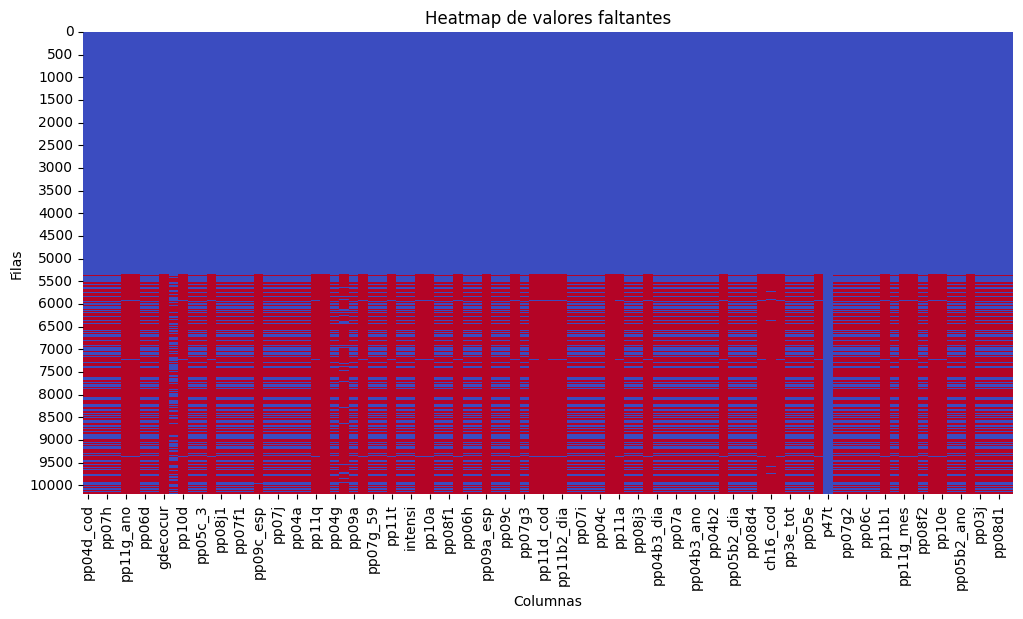

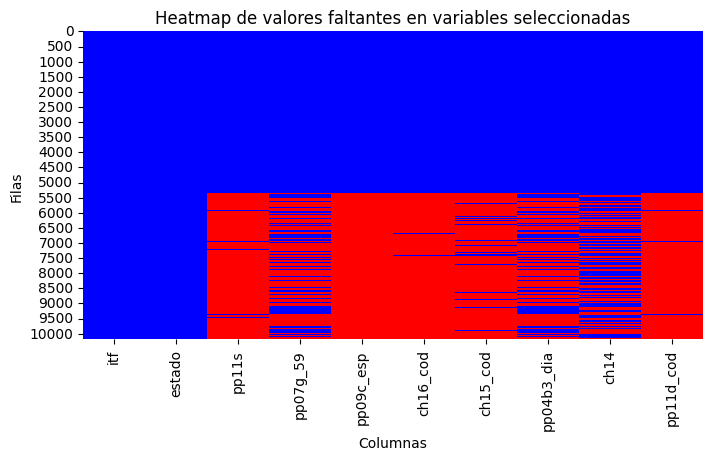

In [7]:
print(matching_columns)
# Identificamos las columnas con valores faltantes y creamos un dataframe
columns_with_missing_values = [col for col in matching_columns if df_combined[col].isnull().any()]
df_combined_filtered = df_combined[columns_with_missing_values]

print(df_combined_filtered.columns.tolist())

# Creamos un heatmap con las variables faltantes
plt.figure(figsize=(12, 6))
sns.heatmap(df_combined_filtered.isnull(), cbar=False, cmap="coolwarm")
plt.title("Heatmap de valores faltantes")
plt.xlabel("Columnas")
plt.ylabel("Filas")
# Configurar ticks del eje y cada 500
num_rows = df_combined_filtered.shape[0]  # Total de filas en el DataFrame
y_ticks = range(0, num_rows + 1, 500)  # Crear ticks de 0 a num_rows en pasos de 500
plt.yticks(ticks=y_ticks, labels=[str(y) for y in y_ticks])  # Aplicar los ticks al eje y
plt.show()

# Elegimos 10 variables
# Tomamos 8 variables con patrones faltantes distintos y agregamos el ingreso total familiar y el estado
diez_heatmap = ['itf', 'estado', 'pp11s', 'pp07g_59', 'pp09c_esp', 'ch16_cod', 'ch15_cod', 'pp04b3_dia', 'ch14', 'pp11d_cod']

# Creamos el dataframe con estas 10 variables para realizar el heatmap
df_combined_diez = df_combined[diez_heatmap]

plt.figure(figsize=(8, 4))
sns.heatmap(df_combined_diez.isnull(), cbar=False, cmap="bwr")
plt.title("Heatmap de valores faltantes en variables seleccionadas")
plt.xlabel("Columnas")
plt.ylabel("Filas")
# Configurar ticks del eje y cada 500
num_rows10 = df_combined_diez.shape[0]  # Total de filas en el DataFrame
y_ticks10 = range(0, num_rows10 + 1, 500)  # Crear ticks de 0 a num_rows en pasos de 500
plt.yticks(ticks=y_ticks10, labels=[str(y) for y in y_ticks10])  # Aplicar los ticks al eje y
plt.show()


Limpieza de la base de datos

In [8]:
# Iteramos buscando tipos de datos que no coinciden
for col in matching_columns:
    dtype_2004 = df_2004_nea[col].dtype
    dtype_2024 = df_2024_nea[col].dtype

    if dtype_2004 != dtype_2024:
        print(f"\n⚠️ Tipo de datos no coincide en columna: '{col}':")
        print(f"  df_2004_nea: {dtype_2004}")
        print(f"  df_2024_nea: {dtype_2024}")

        # Vemos 5 valores no nulos para darnos una idea de la discrepancia
        non_na_2004 = df_2004_nea[col].dropna()
        non_na_2024 = df_2024_nea[col].dropna()

        print(f"  Sample values from df_2004_nea['{col}']:", non_na_2004.sample(min(5, len(non_na_2004)), random_state=1).tolist())
        print(f"  Sample values from df_2024_nea['{col}']:", non_na_2024.sample(min(5, len(non_na_2024)), random_state=1).tolist())


# Creamos una copia del dataframe combinado para no perderlo
df_combined_tydy = df_combined.copy()




⚠️ Tipo de datos no coincide en columna: 'pp04d_cod':
  df_2004_nea: object
  df_2024_nea: float64
  Sample values from df_2004_nea['pp04d_cod']: ['     ', '     ', '     ', '80314', '     ']
  Sample values from df_2024_nea['pp04d_cod']: [99997.0, 82313.0, 72314.0, 57113.0, 5002.0]

⚠️ Tipo de datos no coincide en columna: 'nro_hogar':
  df_2004_nea: float64
  df_2024_nea: int64
  Sample values from df_2004_nea['nro_hogar']: [1.0, 1.0, 1.0, 1.0, 1.0]
  Sample values from df_2024_nea['nro_hogar']: [1, 1, 1, 1, 1]

⚠️ Tipo de datos no coincide en columna: 'pp05f':
  df_2004_nea: category
  df_2024_nea: float64
  Sample values from df_2004_nea['pp05f']: [0.0, 0.0, 0.0, 0.0, 0.0]
  Sample values from df_2024_nea['pp05f']: [7.0, 0.0, 0.0, 7.0, 7.0]

⚠️ Tipo de datos no coincide en columna: 'pp07h':
  df_2004_nea: category
  df_2024_nea: float64
  Sample values from df_2004_nea['pp07h']: [0.0, 0.0, 0.0, 'No', 0.0]
  Sample values from df_2024_nea['pp07h']: [0.0, 2.0, 2.0, 0.0, 0.0]

⚠️ Tip

Reemplazos de tipo de dato

In [86]:
# Observamos valores unicos de variables
# Verificacion individual
print(df_combined_tydy["ch06"].unique())

print(df_combined_tydy["nivel_ed"].dtypes)

print(df_combined_tydy["v10_m"].unique())
print(df_combined_tydy["v10_m"].dtypes)

print(df_combined_tydy["p21"].unique())
print(df_combined_tydy["p21"].dtypes)

print(df_combined_tydy["v9_m"].unique())
print(df_combined_tydy["v9_m"].dtypes)

print(df_combined_tydy["v2_m"].unique())
print(df_combined_tydy["v2_m"].dtypes)

print(df_combined_tydy["nro_hogar"].unique())
print(df_combined_tydy["nro_hogar"].dtypes)

print(df_combined_tydy["v12_m"].unique())
print(df_combined_tydy["v12_m"].dtypes)

print(df_combined_tydy["v8_m"].unique())
print(df_combined_tydy["v8_m"].dtypes)

print(df_combined_tydy["v3_m"].unique())
print(df_combined_tydy["v3_m"].dtypes)

print(df_combined_tydy["v4_m"].unique())
print(df_combined_tydy["v4_m"].dtypes)

print(df_combined_tydy["v21_m"].unique())
print(df_combined_tydy["v21_m"].dtypes)

print(df_combined_tydy["v19_am"].unique())
print(df_combined_tydy["v19_am"].dtypes)

print(df_combined_tydy["v18_m"].unique())
print(df_combined_tydy["v18_m"].dtypes)

print(df_combined_tydy["v11_m"].unique())
print(df_combined_tydy["v11_m"].dtypes)

print(df_combined_tydy["ano4"].unique())
print(df_combined_tydy["ano4"].dtypes)

print(df_combined_tydy["ipcf"].unique())
print(df_combined_tydy["ipcf"].dtypes)

print(df_combined_tydy["p47t"].unique())
print(df_combined_tydy["p47t"].dtypes)

print(df_combined_tydy["v5_m"].unique())
print(df_combined_tydy["v5_m"].dtypes)

print(df_combined_tydy["itf"].unique())
print(df_combined_tydy["itf"].dtypes)

print(df_combined_tydy["tot_p12"].unique())
print(df_combined_tydy["tot_p12"].dtypes)

print(df_combined_tydy["pp11g_ano"].unique())
print(df_combined_tydy["pp11g_ano"].dtypes)

print(df_combined_tydy["pp11b2_mes"].unique())
print(df_combined_tydy["pp11b2_mes"].dtypes)

print(df_combined_tydy["pp08j3"].unique())
print(df_combined_tydy["pp08j3"].dtypes)

print(df_combined_tydy["pp08j1"].unique())
print(df_combined_tydy["pp08j1"].dtypes)

print(df_combined_tydy["pp08f1"].unique())
print(df_combined_tydy["pp08f1"].dtypes)

print(df_combined_tydy["pp08d4"].unique())
print(df_combined_tydy["pp08d4"].dtypes)

print(df_combined_tydy["pp06d"].unique())
print(df_combined_tydy["pp06d"].dtypes)

print(df_combined_tydy["pp3e_tot"].unique())
print(df_combined_tydy["pp3e_tot"].dtypes)

print(df_combined_tydy["pp3f_tot"].unique())
print(df_combined_tydy["pp3f_tot"].dtypes)

print(df_combined_tydy["pp04b2"].unique())
print(df_combined_tydy["pp04b2"].dtypes)

print(df_combined_tydy["pp04b3_dia"].unique())
print(df_combined_tydy["pp04b3_dia"].dtypes)

print(df_combined_tydy["pp06c"].unique())
print(df_combined_tydy["pp06c"].dtypes)

print(df_combined_tydy["pp3e_tot"].unique())
print(df_combined_tydy["pp3e_tot"].dtypes)

print(df_combined_tydy["pp11b2_mes"].unique())
print(df_combined_tydy["pp11b2_mes"].dtypes)

print(df_combined_tydy["pp08j2"].unique())
print(df_combined_tydy["pp08j2"].dtypes)

print(df_combined_tydy["pp08f2"].unique())
print(df_combined_tydy["pp08f2"].dtypes)

print(df_combined_tydy["pp08d1"].unique())
print(df_combined_tydy["pp08d1"].dtypes)

print(df_combined_tydy["codusu"].unique())
print(df_combined_tydy["codusu"].dtypes)

print(df_combined_tydy["nro_hogar"].unique())
print(df_combined_tydy["nro_hogar"].dtypes)

print(df_combined_tydy["componente"].unique())
print(df_combined_tydy["componente"].dtypes)


object


In [12]:
def convertir_float(df, cols):
    for col in cols:
        # # Reemplazamos espacios en blanco con faltantes
        df[col] = df[col].apply(lambda x: pd.NA if isinstance(x, str) and x.strip() == '' else x)
        # Convertimos valores no nulos a floats
        df[col] = df[col].apply(lambda x: float(x) if pd.notna(x) else x)

def convertir_int(df, cols):
    for col in cols:
        # Reemplazamos espacios en blanco con faltantes
        df[col] = df[col].apply(lambda x: pd.NA if isinstance(x, str) and x.strip() == '' else x)
        # Convertir a numero entero
        df[col] = pd.to_numeric(df[col], errors='coerce').astype(pd.Int64Dtype())

def convertir_string(df, cols):
    for col in cols:
        # Convertimos valores no nulos a string
        df[col] = df[col].apply(lambda x: str(x) if pd.notna(x) else x)

def convertir_categorical(df, cols):
    for col in cols:
        # Convertimos la columna a tipo categoría
        df[col] = df[col].astype('category')


# Definimos las listas para convertir
cols_to_int = ['ch06', 'ano4', "v9_m"]
cols_to_float = ['v10_m', 'p21', "v8_m", "v3_m", "pp08j2", "pp08f2", "pp08d1"]
cols_to_string = []
cols_to_categorical = []


# Aplicamos la función de conversión con las listas definidas
convertir_int(df_combined_tydy, cols_to_int)

convertir_float(df_combined_tydy, cols_to_float)
# convertir_string(df_combined_tydy, cols_to_string)
# convertir_categorical(df_combined_tydy, cols_to_categorical)

# Verificamos
print(df_combined_tydy.dtypes)


codusu         object
nro_hogar     float64
componente     object
h15            object
ano4            Int64
               ...   
ch05           object
imputa        float64
pondiio       float64
pondii        float64
pondih        float64
Length: 181, dtype: object


Eliminación de valores negativos


In [10]:
def identify_negatives(df, cols, preview=False):
    """
    Revisa múltiples columnas y detecta en cuáles hay valores negativos.

    Retorna:
    - Lista de columnas con al menos un valor negativo.
    - Diccionario con las filas negativas por columna (opcional)
    """
    hay_negativos = []
    negativos_por_columna = {}

    for col in cols:
        if col in df.columns:
            negativos = df[df[col] < 0]
            if not negativos.empty:
                hay_negativos.append(col)
                negativos_por_columna[col] = negativos
                if preview:
                    print(f"⚠️ Valores negativos en '{col}':")
                    print(negativos[[col]].head(), "\n")
            else:
                if preview:
                    print(f"✔️ Sin negativos en '{col}'.")

    return hay_negativos, negativos_por_columna

# Especificamos las columnas que se deben inspeccionar en busca de valores negativos
id_negativos = ['ipcf', 'ch06', 'p21', "v2_m", 'v10_m', 'p47t', 'itf', 'v5_m', "v12_m",
                "v8_m", "v3_m", "pp08j2", "pp08f2", "pp08d1", "t_vi", "pp06c",
                "v21_m", "v18_m", "v11_m", "tot_p12", "pp08j1", "pp08f1", "pp08d4", "pp06d", "pp3e_tot"]

# Llamamos a la función
hay_negativos, negativos_detalle = identify_negatives(df_combined_tydy, id_negativos, preview=True)

print("Columnas con valores negativos:", hay_negativos) # Lista con columnas en las que vimos numeros negativos



def replace_negs(df, cols):
    """
    Reemplaza números negativos con NaN en las columnas especificadas del DataFrame.

    Parámetros:
    - df (pd.DataFrame): DataFrame a modificar.
    - cols (lista): Lista con nombre/s de columnas para reemplazar.
    """
    for col in cols:
        df[col] = df[col].apply(lambda x: np.nan if pd.notna(x) and x < 0 else x)

# Llamamos a la función
replace_negs(df_combined_tydy, hay_negativos)

print("Columnas con valores negativos luego del reemplazo:", identify_negatives(df_combined_tydy, id_negativos, preview=True))

✔️ Sin negativos en 'ipcf'.
⚠️ Valores negativos en 'ch06':
      ch06
5368    -1
5456    -1
5670    -1
5839    -1
5876    -1 

⚠️ Valores negativos en 'p21':
      p21
5344 -9.0
5345 -9.0
5348 -9.0
5350 -9.0
5361 -9.0 

⚠️ Valores negativos en 'v2_m':
      v2_m
5343  -9.0
5353  -9.0
5362  -9.0
5793  -9.0
5978  -9.0 

⚠️ Valores negativos en 'v10_m':
      v10_m
6192   -9.0
8623   -9.0
9547   -9.0 

⚠️ Valores negativos en 'p47t':
      p47t
5343  -9.0
5344  -9.0
5345  -9.0
5348  -9.0
5350  -9.0 

✔️ Sin negativos en 'itf'.
✔️ Sin negativos en 'v5_m'.
⚠️ Valores negativos en 'v12_m':
      v12_m
6010   -9.0
6016   -9.0
6049   -9.0
6053   -9.0
6599   -9.0 

⚠️ Valores negativos en 'v8_m':
      v8_m
5486  -9.0
5561  -9.0
5677  -9.0
7101  -9.0
7246  -9.0 

⚠️ Valores negativos en 'v3_m':
      v3_m
7758  -9.0
9714  -9.0 

✔️ Sin negativos en 'pp08j2'.
⚠️ Valores negativos en 'pp08f2':
      pp08f2
9913    -9.0 

⚠️ Valores negativos en 'pp08d1':
      pp08d1
5344    -9.0
5345    -9.0
53

Corrección de variables ingreso

In [14]:
columnas_ingreso = ['ipcf', 'p47t', 'itf', 'p21', "v2_m", 'v10_m', 'v5_m',
                    "v8_m", "v3_m", "pp08j2", "pp08f2", "pp08d1", "t_vi", "pp06c",
                    "v21_m", "v18_m", "v11_m", "tot_p12", "pp08j1", "pp08f1",
                    "pp08d4", "pp06d"]

# Ajuste en pesos reales
factor_2004_a_2024 = 62825.74 / 100  # ≈ 628.26

# Ajuste en dólares corrientes y luego a reales
tipo_cambio_anual = {
    2004: 2.86,
    2024: 858.00
}

cpi_usa = {
    2004: 187.4,
    2024: 312.332
}

cpi_base = cpi_usa[2024]
ajuste_dolar = {a: cpi_base / v for a, v in cpi_usa.items()}

# Crear un nuevo DataFrame con los valores originales y ajustados
df_comparacion = df_combined_tydy[['ano4'] + columnas_ingreso].copy()

# Agregar columnas ajustadas
for col in columnas_ingreso:
    df_comparacion[col + '_real2024'] = df_combined_tydy.apply(
        lambda row: row[col] * factor_2004_a_2024 if row['ano4'] == 2004 else row[col],
        axis=1
    )
    df_comparacion[col + '_usd_const_2024'] = df_combined_tydy.apply(
        lambda row: (row[col] / tipo_cambio_anual.get(row['ano4'], 1)) * ajuste_dolar.get(row['ano4'], 1),
        axis=1
    )


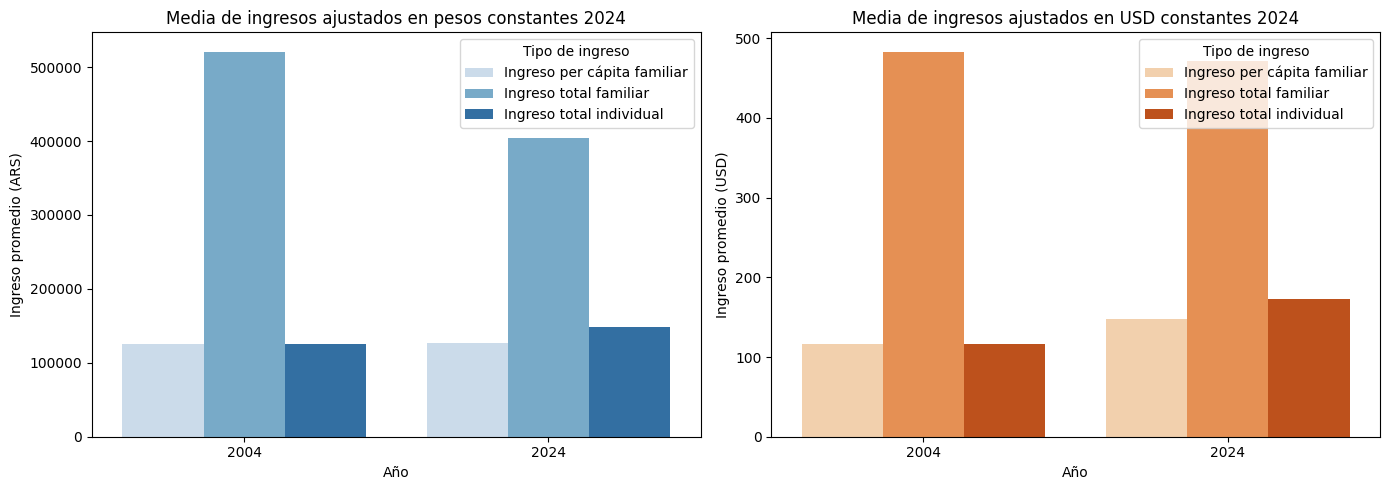

In [17]:
# Reconstruimos df_long desde df_comparacion para calcular 'medias'

# Simulamos nuevamente la estructura si df_comparacion existe
# y contiene las columnas ajustadas 'ipcf', 'p47t', 'itf'
df_comparacion_long = pd.melt(
    df_comparacion[df_comparacion['ano4'].isin([2004, 2024])],
    id_vars='ano4',
    value_vars=[
        'ipcf_real2024', 'ipcf_usd_const_2024',
        'p47t_real2024', 'p47t_usd_const_2024',
        'itf_real2024', 'itf_usd_const_2024'
    ],
    var_name='variable',
    value_name='valor'
)

df_comparacion_long['ajuste'] = df_comparacion_long['variable'].apply(lambda x: 'Pesos reales' if 'real2024' in x else 'USD constantes')
df_comparacion_long['variable_base'] = df_comparacion_long['variable'].str.extract(r'^(ipcf|p47t|itf)')

# Calculamos medias nuevamente
medias = df_comparacion_long.groupby(['variable_base', 'ano4', 'ajuste'])['valor'].mean().reset_index()

# Volvemos a graficar con la variable 'medias' reconstruida
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Gráfico 1: Pesos reales
sns.barplot(
    data=medias[medias['ajuste'] == 'Pesos reales'],
    x='ano4', y='valor', hue='variable_base',
    ax=axes[0], palette='Blues'
)
axes[0].set_title("Media de ingresos ajustados en pesos constantes 2024")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Ingreso promedio (ARS)")
# Modificamos la leyenda del gráfico
legend = axes[0].legend(title="Tipo de ingreso", loc="upper right")
# Cambiamos las etiquetas
for text in legend.get_texts():
    if text.get_text() == 'ipcf':
        text.set_text('Ingreso per cápita familiar')
    elif text.get_text() == 'p47t':
        text.set_text('Ingreso total individual')
    elif text.get_text() == 'itf':
        text.set_text('Ingreso total familiar')

# Gráfico 2: USD constantes
sns.barplot(
    data=medias[medias['ajuste'] == 'USD constantes'],
    x='ano4', y='valor', hue='variable_base',
    ax=axes[1], palette='Oranges'
)
axes[1].set_title("Media de ingresos ajustados en USD constantes 2024")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Ingreso promedio (USD)")
# Modificamos la leyenda del gráfico
legend = axes[1].legend(title="Tipo de ingreso", loc="upper right")
# Cambiamos las etiquetas
for text in legend.get_texts():
    if text.get_text() == 'ipcf':
        text.set_text('Ingreso per cápita familiar')
    elif text.get_text() == 'p47t':
        text.set_text('Ingreso total individual')
    elif text.get_text() == 'itf':
        text.set_text('Ingreso total familiar')

plt.tight_layout()
plt.show()


In [18]:
df_combined_tydy_sin_ajuste = df_combined_tydy.copy()

# Reemplazamos las columnas originales con sus versiones ajustadas en pesos constantes
for col in columnas_ingreso:
    col_ajustada = col + '_real2024'
    df_combined_tydy[col] = df_comparacion[col_ajustada]

# Vemos que los valores cambiaron
cambios_t_vi = df_combined_tydy_sin_ajuste['t_vi'] != df_combined_tydy['t_vi']
print(df_combined_tydy_sin_ajuste[cambios_t_vi][['ano4', 't_vi']].head())
print(df_combined_tydy[cambios_t_vi][['ano4', 't_vi']].head())


    ano4   t_vi
0   2004  465.0
1   2004  454.0
2   2004  250.0
7   2004  500.0
13  2004  150.0
    ano4         t_vi
0   2004  292139.6910
1   2004  285228.8596
2   2004  157064.3500
7   2004  314128.7000
13  2004   94238.6100


Reemplazo de categóricas y Eliminacion de valores sin sentido

In [19]:
# Diccionarios EPH con claves numéricas

ch04_dict = {1: 'Varón', 2: 'Mujer'}

ch07_dict = {1: 'Unido',
 2: 'Casado',
 3: 'Separado o divorciado',
 4: 'Viudo',
 5: 'Soltero'}

ch08_dict = {1: 'Obra social (incluye PAMI)',
 2: 'Mutual/Prepaga/Servicio de emergencia',
 3: 'Planes y seguros públicos',
 4: 'No paga ni le descuentan',
 9: 'Ns./Nr.',
 12: 'Obra social y mutual/prepaga/servicio de emergencia',
 13: 'Obra social y Planes y Seguros Públicos',
 23: 'Mutual / Prepaga / Servicio de emergencia y Planes y Seguros Públicos',
 123: 'Obra social, Mutual / Prepaga / Servicio de emergencia y Planes y '
      'Seguros Públicos'}

nivel_ed_dict = {1: 'Primaria Incompleta (incluye educación especial)',
 2: 'Primaria Completa',
 3: 'Secundaria Incompleta',
 4: 'Secundaria Completa',
 5: 'Superior Universitaria Incompleta',
 6: 'Superior Universitaria Completa',
 7: 'Sin instrucción',
 9: 'Ns./Nr.'}

estado_dict = {0: 'Entrevista no realizada',
 1: 'Ocupado',
 2: 'Desocupado',
 3: 'Inactivo',
 4: 'Menor de 10 años'}

cat_ocup_dict = {1: 'Patrón',
 2: 'Cuenta propia',
 3: 'Obrero o empleado',
 4: 'Trabajador familiar sin remuneración',
 9: 'Ns./Nr.'}

cat_inac_dict = {1: 'Jubilado/pensionado',
 2: 'Rentista',
 3: 'Estudiante',
 4: 'Ama de casa',
 5: 'Menor de 6 años',
 6: 'Discapacitado',
 7: 'Otros'}

region_dict = {1: 'Gran Buenos Aires',
 40: 'NOA',
 41: 'NEA',
 42: 'Cuyo',
 43: 'Pampeana',
 44: 'Patagonia'}

trimestre_dict = {1: '1er. Trimestre', 2: '2° trimestre', 3: '3° trimestre', 4: '4° trimestre'}

mas_500_dict = {'N': 'Menos de 500.000 habitantes', 'S': '500.000 habitantes o más'}

aglomerado_dict = {7: 'Posadas', 8: 'Gran Resistencia', 12: 'Corrientes', 15: 'Formosa'}

ch09_dict = {1: 'Sí', 2: 'No', 3: 'Menor de 2 años'}

ch10_dict = {1: 'Sí, asiste', 2: 'No asiste, pero asistió', 3: 'Nunca asistió'}

ch11_dict = {1: 'Público', 2: 'Privado', 9: 'Ns./Nr.'}

ch13_dict = {1: 'Sí', 2: 'No', 3: 'Ns./Nr.'}

ch14_dict = {0: 'Ninguno',
 1: 'Primero',
 2: 'Segundo',
 3: 'Tercero',
 4: 'Cuarto',
 5: 'Quinto',
 6: 'Sexto',
 7: 'Séptimo',
 8: 'Octavo',
 9: 'Noveno',
 98: 'Educación especial',
 99: 'Ns/Nr'}

ch15_dict = {1: 'En esta localidad',
 2: 'En otra localidad',
 3: 'En otra provincia (especificar)',
 4: 'En un país limítrofe',
 5: 'En otro país',
 6: 'No había nacido',
 9: 'Ns./Nr.'}

ch16_dict = {1: 'En esta localidad',
 2: 'En otra localidad de esta provincia',
 3: 'En otra provincia (especificar)',
 4: 'En un país limítrofe',
 5: 'En otro país',
 6: 'No había nacido',
 9: 'Ns./Nr.'}

intensi_dict = {1: 'Subocupación horaria Demandante',
 2: 'Subocupación horaria No Demandante',
 3: 'Ocupación plena',
 4: 'Sobreocupación horaria',
 5: 'Ocupado que no trabajó en la semana',
 9: 'Ns./Nr.'}

pp02c1_dict = {1: 'Sí', 2: 'No'}

pp02c2_dict = {1: 'Sí', 2: 'No'}

pp02c3_dict = {1: 'Sí', 2: 'No'}

pp02c4_dict = {1: 'Sí', 2: 'No'}

pp02c5_dict = {1: 'Sí', 2: 'No'}

pp02c6_dict = {1: 'Sí', 2: 'No'}

pp02c7_dict = {1: 'Sí', 2: 'No'}

pp02c8_dict = {1: 'Sí', 2: 'No'}

pp02e_dict = {1: 'Está suspendido',
 2: 'Ya tiene trabajo asegurado',
 3: 'Se cansó de buscar trabajo',
 4: 'Hay poco trabajo en esta época del año',
 5: 'Por otras razones'}

pp02h_dict = {1: 'Sí', 2: 'No'}

pp02i_dict = {1: 'Sí', 2: 'No'}

pp03g_dict = {1: 'Sí', 2: 'No'}

pp03h_dict = {1: '...podía trabajarlas esa semana?',
 2: '...podía empezar a trabajarlas en dos semanas a más tardar?',
 3: '...no podía trabajar más horas?',
 9: 'Ns/Nr'}

pp04c_dict = {1: '1 persona',
 2: '2 personas',
 3: '3 personas',
 4: '4 personas',
 5: '5 personas',
 6: 'de 6 a 10 personas',
 7: 'de 11 a 25 personas',
 8: 'de 26 a 40 personas',
 9: 'de 41 a 100 personas',
 10: 'de 101 a 200 personas',
 11: 'de 201 a 500 personas',
 12: 'más de 500 personas',
 99: 'Ns./Nr.'}

pp04g_dict = {1: 'En un local/oficina/establecimiento/negocio/taller/chacra/fi',
 2: 'En puesto o kiosco fijo callejero',
 3: 'En vehículos: bicicleta/moto/auto/barco/bote (no incluye ser',
 4: 'En vehículo para transporte de personas y mercaderías-aéreo,',
 5: 'En obras en construcción, de infraestructura, minería o simi',
 6: 'En esta vivienda',
 7: 'En la vivienda del socio o del patrón',
 8: 'En el domicilio/local de los clientes',
 9: 'En la calle/espacios públicos/ambulante/de casa en casa/pues',
 10: 'En otro lugar'}

vii1_1_dict = {96: 'Servicio doméstico',
 97: 'Otra persona que no vive en el hogar',
 98: 'Ninguna'}

vii1_2_dict = {96: 'Servicio doméstico',
 97: 'Otra persona que no vive en el hogar',
 98: 'Ninguna'}

vii2_1_dict = {96: 'Servicio doméstico',
 97: 'Otra persona que no vive en el hogar',
 98: 'Ninguna'}

vii2_2_dict = {96: 'Servicio doméstico',
 97: 'Otra persona que no vive en el hogar',
 98: 'Ninguna'}

vii2_3_dict = {96: 'Servicio doméstico',
 97: 'Otra persona que no vive en el hogar',
 98: 'Ninguna'}

vii2_4_dict = {96: 'Servicio doméstico',
 97: 'Otra persona que no vive en el hogar',
 98: 'Ninguna'}

iv1_dict = {1: 'Casa',
 2: 'Departamento',
 3: 'Pieza de inquilinato',
 4: 'Pieza en hotel / pensión',
 5: 'Local no construido para habitación',
 6: 'Otros'}

ch12_dict = {1: 'Jardín/Preescolar',
 2: 'Primario',
 3: 'EGB',
 4: 'Secundario',
 5: 'Polimodal',
 6: 'Terciario',
 7: 'Universitario',
 8: 'Posgrado Universitario',
 9: 'Educación especial (discapacitado)'}


In [87]:
# Funcion que mapea los valores numéricos a diccionario

def mapear_categoricos_con_alertas(df):
    """
    Mapea y limpia variables categóricas:
    - Usa diccionarios definidos manualmente
    - Detecta columnas decil y les aplica un único diccionario común
    - Convierte strings como '01', ' 1', '10' correctamente
    - Preserva valores ya mapeados
    - Alerta si se pierden datos
    """

    # Diccionario base para deciles
    dict_deciles = {
        0: 'Sin ingresos',
        1: 'Decil 1', 2: 'Decil 2', 3: 'Decil 3', 4: 'Decil 4', 5: 'Decil 5',
        6: 'Decil 6', 7: 'Decil 7', 8: 'Decil 8', 9: 'Decil 9', 10: 'Decil 10',
        12: 'No respuesta de ingresos',
        13: 'Entrevista individual no realizada'
    }

    # Lista ampliada de nombres de variables decil
    decile_variables = {
        'deccfr', 'decifr', 'rdeccfr', 'gdeccfr', 'pdeccfr', 'adecifr',
        'decocur', 'idecocur', 'rdecocur', 'gdecocur',
        'decindr', 'idecindr', 'rdecindr', 'gdecindr', 'pdecindr', 'adecindr',
        'rdecifr', 'gdecifr', 'pdecifr', 'idecifr'
    }

    df_copy = df.copy()
    columnas_mapeadas = []

    # Reunimos los mapeos predefinidos
    mapeos = {
        'ch04': ch04_dict, 'ch07': ch07_dict, 'ch08': ch08_dict, 'nivel_ed': nivel_ed_dict,
        'estado': estado_dict, 'cat_ocup': cat_ocup_dict, 'cat_inac': cat_inac_dict,
        'region': region_dict, 'trimestre': trimestre_dict, 'mas_500': mas_500_dict,
        'aglomerado': aglomerado_dict, 'ch09': ch09_dict, 'ch10': ch10_dict, 'ch11': ch11_dict,
        'ch13': ch13_dict, 'ch14': ch14_dict, 'ch15': ch15_dict, 'ch16': ch16_dict,
        'intensi': intensi_dict,
        'pp02c1': pp02c1_dict, 'pp02c2': pp02c2_dict, 'pp02c3': pp02c3_dict, 'pp02c4': pp02c4_dict,
        'pp02c5': pp02c5_dict, 'pp02c6': pp02c6_dict, 'pp02c7': pp02c7_dict, 'pp02c8': pp02c8_dict,
        'pp02e': pp02e_dict, 'pp02h': pp02h_dict, 'pp02i': pp02i_dict, 'pp03g': pp03g_dict,
        'pp03h': pp03h_dict, 'pp04c': pp04c_dict, 'pp04g': pp04g_dict,
        'vii1_1': vii1_1_dict, 'vii1_2': vii1_2_dict,
        'vii2_1': vii2_1_dict, 'vii2_2': vii2_2_dict,
        'vii2_3': vii2_3_dict, 'vii2_4': vii2_4_dict,
        'iv1': iv1_dict, 'ch12': ch12_dict
    }

    for col in df.columns: # Mapeo normal y de deciles
        col_lower = col.lower()
        if col in mapeos:
            dic = mapeos[col]
        elif col_lower in decile_variables:
            dic = dict_deciles
        else:
            continue  # no se mapea esta columna

        # Guardamos el conjunto de valores y claves, verificando que sean string
        original_values = df_copy[col].copy()
        valores_objetivo = set(dic.values())
        claves_dict = set(dic.keys())
        claves_son_strings = all(isinstance(k, str) for k in claves_dict)

        # Función que mapea cada valor x en la columna
        def convertir_valor(x):
            if x in valores_objetivo: # si ya coincide no se altera
                return x
            if isinstance(x, str): # si es string eliminamos espacios sobrantes
                x = x.strip()
                if x == '':
                    return np.nan
                if not claves_son_strings: # si no es string, intenta hacerlo int
                    try:
                        x = int(float(x))
                    except ValueError: # si no, lo pasa a faltante
                        return np.nan
            return dic.get(x, np.nan)
        # Aplicamos el mapeo
        df_copy[col] = df_copy[col].apply(convertir_valor)

        # Verificamos valores perdidos (nuevos faltantes)
        nuevos_nan = df_copy[col].isna() & original_values.notna()
        if nuevos_nan.sum() > 0:
            print(f"⚠️ {col}: {nuevos_nan.sum()} valores válidos se convirtieron en NaN tras mapear.")
            print(f"   Ejemplos perdidos: {original_values[nuevos_nan].unique()[:5]}")

        columnas_mapeadas.append(col) # se registran las columnas mapeadas

    return df_copy, columnas_mapeadas

In [88]:
# Se crea un índice que identifique a cada persona
df_combined_tydy = df_combined_tydy.reset_index(drop=True)
df_combined_tydy['id_persona'] = df_combined_tydy.index.astype(str)

# Ejercicios TP1

In [89]:
# Por las dudas vamos a copiar de nuevo el dataframe
df_combined_tydy2 = df_combined_tydy.copy()

In [90]:
def map_with_general_handling(df, column, reverse_mapping, problematic_values=None):
    """
    Asigna valores en la columna especificada según el diccionario de asignación inversa.
    Maneja valores numéricos y strings para que estos coincidan.
    Parámetros:
    - df (pd.DataFrame): DataFrame que se modificará.
    - column (str): El nombre de la columna que se asignará.
    - reverse_mapping (dict): Un diccionario para asignar categorías a valores numéricos.
    - problematic_values ​​(set): Conjunto opcional de valores problemáticos conocidos que se reemplazarán con NaN.
    """
    print(f"Valores unicos en '{column}' antes del mapeo:", df[column].unique())

    df[column] = df[column].apply(
        lambda x: reverse_mapping.get(x, np.nan) if pd.notna(x) and isinstance(x, str) else x
    )

    if problematic_values:
        df[column] = df[column].apply(lambda x: np.nan if x in problematic_values else x)

    print(f"Valores unicos en '{column}' después del mapeo:", df[column].unique())


# Mapear y homogeneizar valores

# ch04: Genero
ch04_mapping = {"Varón": 1, "Mujer": 2}
map_with_general_handling(df_combined_tydy2, 'ch04', ch04_mapping)

# ch07: Relación/estado civil
ch07_mapping = {
    "Unido": 1, "Casado": 2, "Separado o divorciado": 3,
    "Viudo": 4, "Soltero": 5
}
map_with_general_handling(df_combined_tydy2, 'ch07', ch07_mapping)


# ch08: Cobertura de salud
ch08_mapping = {
    "Obra social (incluye PAMI)": 1,
    "Mutual/Prepaga/Servicio de emergencia": 2,
    "Planes y seguros públicos": 3,
    "No paga ni le descuentan": 4,
    "Ns./Nr.": 9,
    "Obra social y mutual/prepaga/servicio de emergencia": 12,
    "Obra social y Planes y Seguros Públicos": 13,
    "Mutual /prepaga / servicio de emergencia / Planes y Seguros Públicos": 23,
    "Obra social, mutual / prepaga / servicio de emergencia y Planes y Seguros Públicos": 123
}
map_with_general_handling(df_combined_tydy2, 'ch08', ch08_mapping)


# nivel_ed: Nivel educativo
nivel_ed_mapping = {
    "Primaria Incompleta (incluye educación especial)": 1,
    "Primaria Completa": 2,
    "Secundaria Incompleta": 3,
    "Secundaria Completa": 4,
    "Superior Universitaria Incompleta": 5,
    "Superior Universitaria Completa": 6,
    "Sin instrucción": 7,
    "Ns./Nr.": 9
}
map_with_general_handling(df_combined_tydy2, 'nivel_ed', nivel_ed_mapping)


# estado: Situación laboral
estado_mapping = {
    "Entrevista individual no realizada (no respuesta al cuestion)": 0,
    "Ocupado": 1, "Desocupado": 2, "Inactivo": 3, "Menor de 10 años": 4
}
map_with_general_handling(df_combined_tydy2, 'estado', estado_mapping)


# cat_inac: Categoría de inactividad
cat_inac_mapping = {
    "Jubilado/pensionado": 1, "Rentista": 2, "Estudiante": 3,
    "Ama de casa": 4, "Menor de 6 años": 5, "Discapacitado": 6, "Otros": 7
}

# Acá vimos que hay un 0.0 que no corresponde a las respuestas esperadas
map_with_general_handling(df_combined_tydy2, 'cat_inac', cat_inac_mapping, problematic_values={0.0})


# Chequeamos el resultado
print(df_combined_tydy2[['nivel_ed', 'ch04', 'ch07', 'ch08', 'estado', 'cat_inac']])


Valores unicos en 'ch04' antes del mapeo: ['Mujer' 'Varón' 2 1]
Valores unicos en 'ch04' después del mapeo: [2 1]
Valores unicos en 'ch07' antes del mapeo: ['Unido' 'Viudo' 'Soltero' 'Casado' 'Separado o divorciado' 4 5 2 3 1]
Valores unicos en 'ch07' después del mapeo: [1 4 5 2 3]
Valores unicos en 'ch08' antes del mapeo: ['Obra social (incluye PAMI)' 'No paga ni le descuentan'
 'Mutual/Prepaga/Servicio de emergencia'
 'Obra social y mutual/prepaga/servicio de emergencia'
 'Planes y seguros públicos' 'Ns./Nr.' 1 4 12 3 2 9]
Valores unicos en 'ch08' después del mapeo: [ 1  4  2 12  3  9]
Valores unicos en 'nivel_ed' antes del mapeo: ['Superior Universitaria Completa'
 'Primaria Incompleta (incluye educación especial)'
 'Secundaria Incompleta' 'Primaria Completa'
 'Superior Universitaria Incompleta' 'Sin instrucción'
 'Secundaria Completa' 4 3 7 6 5 2 1]
Valores unicos en 'nivel_ed' después del mapeo: [6 1 3 2 5 7 4]
Valores unicos en 'estado' antes del mapeo: ['Inactivo' 'Ocupado' 'Men

Ejercicio 3

<IntegerArray>
[2004, 2024]
Length: 2, dtype: Int64
Int64


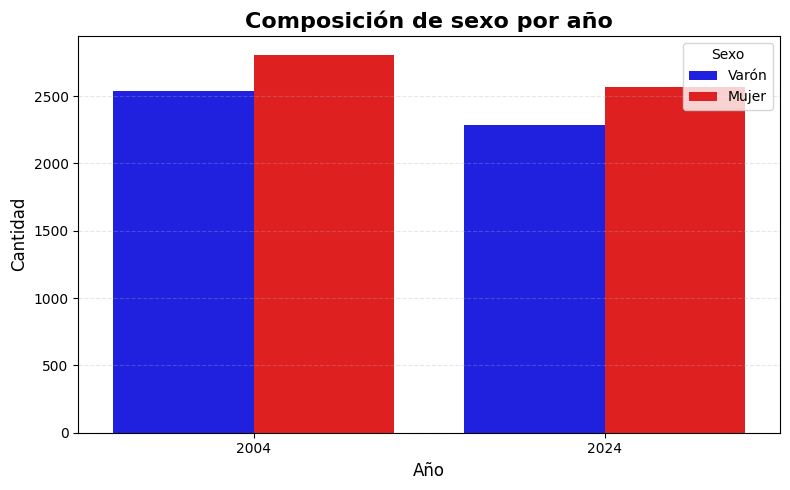

In [91]:
# Nos aseguramos de tener los formatos correctos
print(df_combined_tydy2["ano4"].unique())
print(df_combined_tydy2["ano4"].dtype)

# Agrupar por año y género, luego contar las ocurrencias
gender_mapping = {
    1: "Varón",
    2: "Mujer"}

composition = df_combined_tydy2.groupby(['ano4', 'ch04']).size().reset_index(name='count')

# Mapeamos el género al diccionario que definimos
composition['Gender'] = composition['ch04'].map(gender_mapping)

# Definimos colores personalizados para los géneros
custom_palette = {
    'Varón': 'blue',
    'Mujer': 'red' }

# Ploteo
plt.figure(figsize=(8, 5))
sns.barplot(data=composition, x='ano4', y='count', hue='Gender', palette=custom_palette)

# Ajustes
plt.title("Composición de sexo por año", fontsize=16, fontweight='bold')
plt.xlabel("Año", fontsize=12)
plt.ylabel("Cantidad", fontsize=12)
plt.legend(title="Sexo", loc="upper right")
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Mostramos la figura
plt.tight_layout()
plt.show()

Ejercicio 4

In [26]:
# CORRER DESPUES DEL FINAL DEL TP 1

# Matriz de correlación entre las variables
df_cat_inac = df_mapeado [['cat_inac']].copy()
df_cat_inac = df_cat_inac.replace(valores_a_nan, np.nan)
df_cat_inac_dummies = pd.get_dummies(df_cat_inac, prefix='cat_inac', drop_first=True)

# Nos aseguramos de trabajar sólo con índices sin missing en df_manual_dummies_clean
df_cat_inac_dummies = df_cat_inac_dummies.loc[df_manual_dummies_clean.index]

# Concatenamos horizontalmente
df_dummies_con_cat_inac = pd.concat([df_manual_dummies_clean, df_cat_inac_dummies], axis=1)
print(df_dummies_con_cat_inac.shape)
print(df_dummies_con_cat_inac.columns[-5:])  # Últimas columnas agregadas


vars_corrmatrix = ['ch06', 'ipcf', 'ch04_Varón', 'ch07_Separado o divorciado',
       'ch07_Soltero', 'ch07_Unido', 'ch07_Viudo',
       'nivel_ed_Primaria Incompleta (incluye educación especial)',
       'nivel_ed_Secundaria Completa', 'nivel_ed_Secundaria Incompleta',
       'nivel_ed_Sin instrucción', 'nivel_ed_Superior Universitaria Completa',
       'nivel_ed_Superior Universitaria Incompleta',
       'ch08_No paga ni le descuentan', 'ch08_Obra social (incluye PAMI)',
       'ch08_Obra social y mutual/prepaga/servicio de emergencia',
       'ch08_Planes y seguros públicos', 'cat_inac_Estudiante', 'cat_inac_Jubilado/pensionado',
       'cat_inac_Menor de 6 años', 'cat_inac_Otros', 'cat_inac_Rentista',
       'estado_Entrevista individual no realizada (no respuesta al cuestionario)',
       'estado_Inactivo', 'estado_Menor de 10 años', 'estado_Ocupado']

plt.figure(figsize=(12, 8))
corrmatrix = df_dummies_con_cat_inac[vars_corrmatrix].corr()
sns.heatmap(corrmatrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Variables')
plt.show()

NameError: name 'df_mapeado' is not defined

Ejercicio 5

In [92]:
def contador(df, columna, condicion, anos=None):
    """
    Cuenta la cantidad de veces que se cumpla la condición en una columna.

    Parámetros:
    - df (pd.DataFrame): El DataFrame que se analizará.
    - columna (str): El nombre de la columna donde se contarán las ocurrencias.
    - condición: La condición para el recuento en la columna especificada.
    - años (list): Una lista de años por los que se filtrarán los datos (opcional).

    Devuelve:
    - int: El recuento de veces que la condición aparece en la columna.
    """
    # Si se proporciona anos, filtrar por año
    if anos:
        df = df[df['ano4'].isin(anos)]

    return (df[columna] == condicion).sum()

# Contamos la cantidad de desocupados e inactivos en total:
print(f"Hay {contador(df_combined_tydy2, 'estado', 2)} desocupados")
print(f"Hay {contador(df_combined_tydy2, 'estado', 3)} inactivos")

# Creamos un diccionario que vaya de valores a definiciones
estado_dict = {
    0: "Entrevista individual no realizada (no respuesta al cuestionario)",
    1: "Ocupado",
    2: "Desocupado",
    3: "Inactivo",
    4: "Menor de 10 años"
}

def medias(df, columna_ref, columna_calc, condicion, anos=[2004, 2024]):
    """
    Calcula la media de una columna específica según una condición y uno o más años.

    Parámetros:
    - df (pd.DataFrame): El DataFrame que se analizará.
    - columna_ref (str): El nombre de la columna que se usará para filtrar la condición.
    - columna_calc (str): El nombre de la columna para la que se calculará la media.
    - condicion (n): La condición para filtrar los datos en columna_ref.
    - anos (list): Los años por los que se filtrará (el valor predeterminado es [2004, 2024]).

    Devuelve:
    - dict: Un diccionario con los valores medios de cada año y la media total.
    """
    # Diccionario para almacenar valores medios de cada año y la media total
    mean_values = {}

    # Calcular la media para cada año
    for ano in anos:
        df_filtered = df[(df[columna_ref] == condicion) & (df['ano4'] == ano)]
        mean_values[ano] = df_filtered[columna_calc].mean()

    # Calcular la media total (ignorando el filtro de año)
    df_filtered_total = df[df[columna_ref] == condicion]
    mean_values["Total"] = df_filtered_total[columna_calc].mean()

    return mean_values


# Creamos una lista para luego aplicar la función
# Lo hacemos con Ocupado, Desocupado e Inactivo
condiciones = [1, 2, 3]

for condicion in condiciones:
    # Obtener la frase correspondiente a la condición
    condition_phrase = estado_dict.get(condicion, f"Condicion {condicion}")

    # Obtener los valores medios para cada año (2004 y 2024) y la media total
    mean_by_year = medias(df_combined_tydy2, 'estado', 'ipcf', condicion)

    # Resultado de cada año y el total
    for ano, mean in mean_by_year.items():
        print(f"La media de ingreso per cápita familiar (IPCF) para la condición '{condition_phrase}' "
              f"{'en el año ' + str(ano) if ano != 'Total' else 'en total'} es {round(mean, 2)} pesos")


Hay 342 desocupados
Hay 4284 inactivos
La media de ingreso per cápita familiar (IPCF) para la condición 'Ocupado' en el año 2004 es 153741.47 pesos
La media de ingreso per cápita familiar (IPCF) para la condición 'Ocupado' en el año 2024 es 144161.96 pesos
La media de ingreso per cápita familiar (IPCF) para la condición 'Ocupado' en total es 148556.25 pesos
La media de ingreso per cápita familiar (IPCF) para la condición 'Desocupado' en el año 2004 es 93068.29 pesos
La media de ingreso per cápita familiar (IPCF) para la condición 'Desocupado' en el año 2024 es 85540.11 pesos
La media de ingreso per cápita familiar (IPCF) para la condición 'Desocupado' en total es 90272.74 pesos
La media de ingreso per cápita familiar (IPCF) para la condición 'Inactivo' en el año 2004 es 123188.18 pesos
La media de ingreso per cápita familiar (IPCF) para la condición 'Inactivo' en el año 2024 es 119954.72 pesos
La media de ingreso per cápita familiar (IPCF) para la condición 'Inactivo' en total es 12169

Ejercicio 6

In [94]:
# Contamos quienes no respondieron
print(f"Hay {contador(df_combined_tydy2, 'estado', 0)} personas que no respondieron su condición de actividad")
print(f"Hay {contador(df_combined_tydy2, 'ipcf', 0)} personas que no respondieron su ingreso per cápita familiar")

# Filtrar el DataFrame para las personas que respondieron (estado != 0)
respondieron = df_combined_tydy2[df_combined_tydy2['estado'] != 0]

# Filtramos para personas que no respondieron (estado == 0)
norespondieron = df_combined_tydy2[df_combined_tydy2['estado'] == 0]

# Guardamos cada dataframe como base de excel
respondieron.to_excel('respondieron.xlsx', index=False)
norespondieron.to_excel('norespondieron.xlsx', index=False)


Hay 6 personas que no respondieron su condición de actividad
Hay 983 personas que no respondieron su ingreso per cápita familiar


Ejercicio 7

<ipython-input-95-5481e4f1d12f>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  respondieron.loc[(respondieron['estado'] == 1) | (respondieron['estado'] == 2), 'PEA'] = 1


   estado  PEA
0     3.0  0.0
1     3.0  0.0
2     1.0  1.0
3     1.0  1.0
4     3.0  0.0


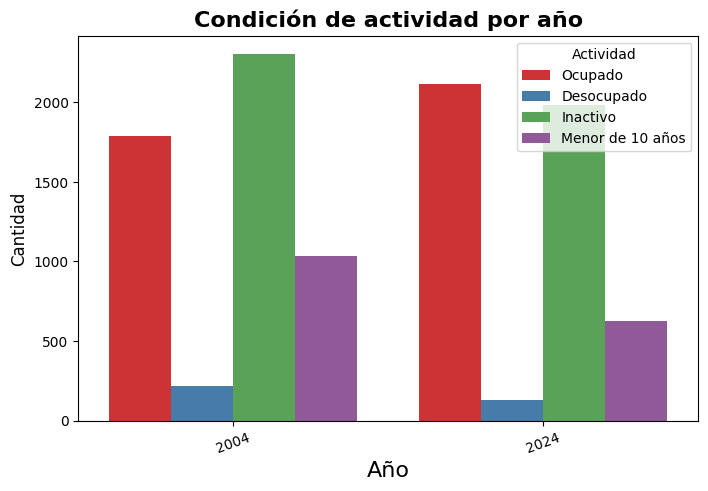

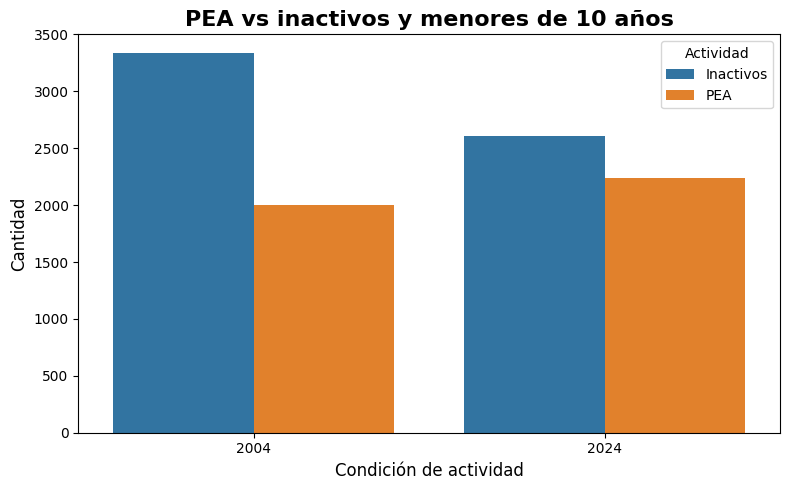

In [95]:
# Iterar sobre la columna 'estado' y establecer la nueva columna 'PEA'
# Asignamos valor 1 si están ocupados o desocupados. 0 sino
respondieron.loc[(respondieron['estado'] == 1) | (respondieron['estado'] == 2), 'PEA'] = 1
respondieron.loc[respondieron['estado'].isin([3, 4]), 'PEA'] = 0

# Chequeamos el resultado
print(respondieron[['estado', 'PEA']].head())

# Diccionario que mapea el valor a la descripción
pea_dict = {
    1: "PEA",
    0: "Inactivos"
}

# Agrupamos por año y actividad
composition = respondieron.groupby(['ano4', 'estado']).size().reset_index(name='count')

composition['Actividad'] = composition['estado'].map(estado_dict)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=composition, x='ano4', y='count', hue='Actividad', palette='Set1')

# Customización
plt.title("Condición de actividad por año", fontsize=16, fontweight='bold')
plt.xlabel("Año", fontsize=16)
plt.ylabel("Cantidad", fontsize=12)
plt.xticks(rotation=20)
plt.legend(title="Actividad", loc="upper right")



# Plot 2: PEA == 1 vs PEA == 0

# Agrupamos por año y PEA
pea_composition = respondieron.groupby(['ano4','PEA']).size().reset_index(name='count')
pea_composition['Actividad'] = pea_composition['PEA'].map(pea_dict)

plt.figure(figsize=(8, 5))
sns.barplot(data=pea_composition, x='ano4', y='count', hue='Actividad', palette='tab10')

# Detalles estéticos para la comparación
plt.title("PEA vs inactivos y menores de 10 años", fontsize=16, fontweight='bold')
plt.xlabel("Condición de actividad", fontsize=12)
plt.ylabel("Cantidad", fontsize=12)
plt.xticks(ticks=[0, 1])
plt.legend(title="Actividad", loc="upper right")

# Mostramos los plots
plt.tight_layout()
plt.show()

Ejercicio 8

<ipython-input-96-5b66a19e5f3c>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  respondieron.loc[(respondieron['ch06'] < 65) & (respondieron['ch06'] >= 15), 'PET'] = 1


      ch06  PET
1231    17  1.0
4754    55  1.0
8114    43  1.0
5017    30  1.0
1367    16  1.0
9424    10  NaN
2547     9  NaN
7055    46  1.0
1425    13  NaN
5914    23  1.0


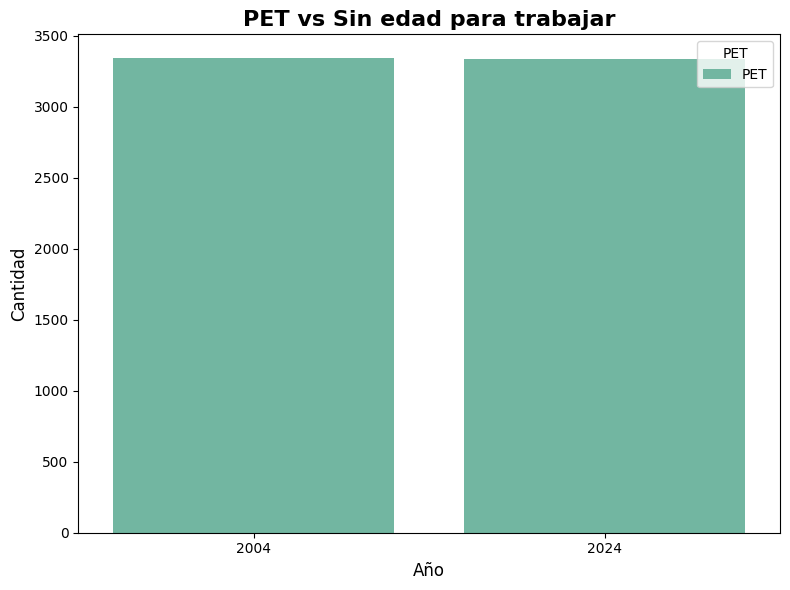

In [96]:
# Iteramos sobre la columna 'ch06' y establecemos la nueva columna 'PET'

# PET == 1 si respondieron aquellos menores de 65 años e iguales o mayores de 15. == 0 sino
respondieron.loc[(respondieron['ch06'] < 65) & (respondieron['ch06'] >= 15), 'PET'] = 1
respondieron.loc[(respondieron['ch06'] >= 65) & (respondieron['ch06'] < 15), 'PET'] = 0

# Chequear el resultado
print(respondieron[['ch06', 'PET']].sample(10))

pet_dict = {
    1: "PET",
    0: "Sin edad para trabajar"
}

# Plot: PET por año (ano4)
composition_pet = respondieron.groupby(['ano4', 'PET']).size().reset_index(name='count')

composition_pet['Actividad'] = composition_pet['PET'].map(pet_dict)

plt.figure(figsize=(8, 6))
sns.barplot(data=composition_pet, x='ano4', y='count', hue='Actividad', palette='Set2')

# Personalizacion del gráfico
plt.title("PET vs Sin edad para trabajar", fontsize=16, fontweight='bold')
plt.xlabel("Año", fontsize=12)
plt.ylabel("Cantidad", fontsize=12)
plt.legend(title="PET", loc="upper right")
plt.xticks(ticks=[0, 1])

plt.tight_layout()
plt.show()

Ejercicio 9

<ipython-input-97-50e3924019a5>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  respondieron.loc[(respondieron['estado'] == 2), 'desocupado'] = 1
<ipython-input-97-50e3924019a5>:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{float(y * 100)}' for y in ax.get_yticks()]) # Queremos ver porcentajes
<ipython-input-97-50e3924019a5>:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=0, ha='center', fontsize=10)


       estado  desocupado
3129      3.0         0.0
6291      1.0         0.0
3724      3.0         0.0
10182     3.0         0.0
7157      3.0         0.0
...       ...         ...
3833      1.0         0.0
5830      1.0         0.0
1279      3.0         0.0
4846      1.0         0.0
8907      4.0         0.0

[100 rows x 2 columns]
La cantidad de personas desocupadas en el año 2004 fue 215
La cantidad de personas desocupadas en el año 2024 fue 127


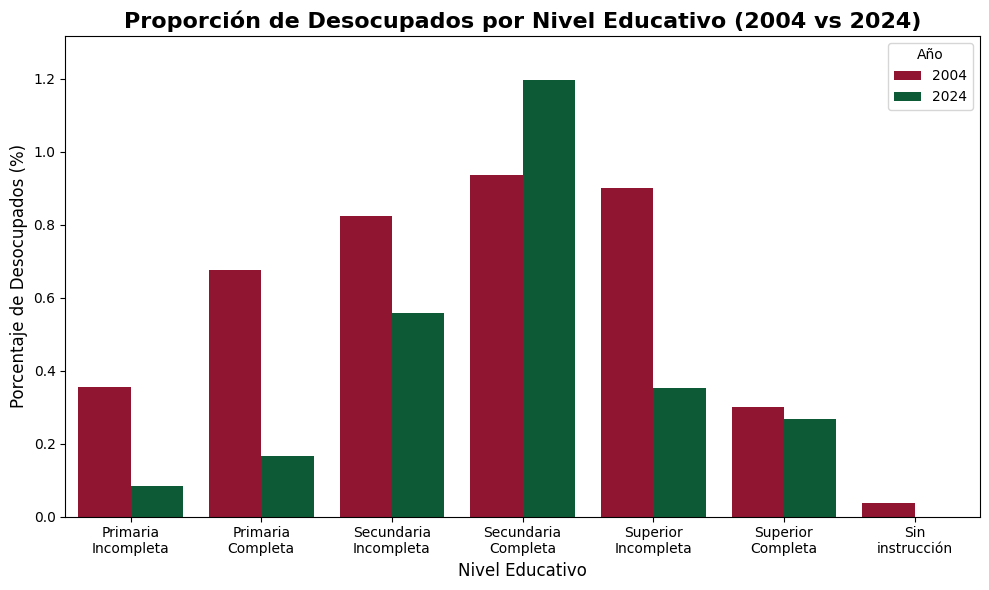

<ipython-input-97-50e3924019a5>:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  respondieron['edad_grupo'] = (respondieron['ch06'] // 10) * 10
<ipython-input-97-50e3924019a5>:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  eje.set_yticklabels([f'{round(float(y * 100), 2)}' for y in eje.get_yticks()]) # Porcentajes con 2 decimales
<ipython-input-97-50e3924019a5>:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  eje.set_xticklabels([f'{x}' for x in edad_grupos_unicos])


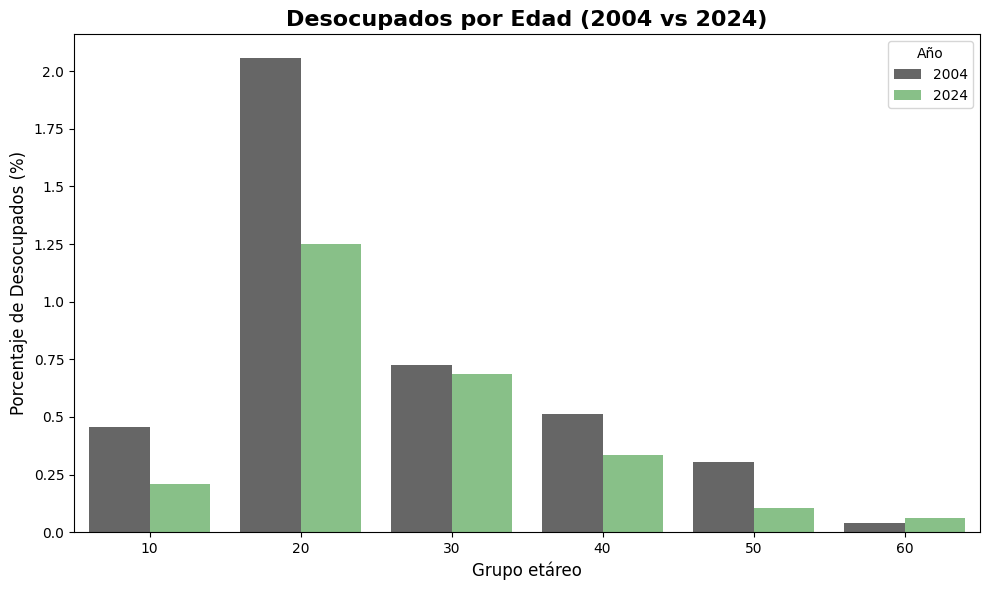

<ipython-input-97-50e3924019a5>:121: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(round(y * 100))}' for y in ax.get_yticks()])
<ipython-input-97-50e3924019a5>:121: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(round(y * 100))}' for y in ax.get_yticks()])


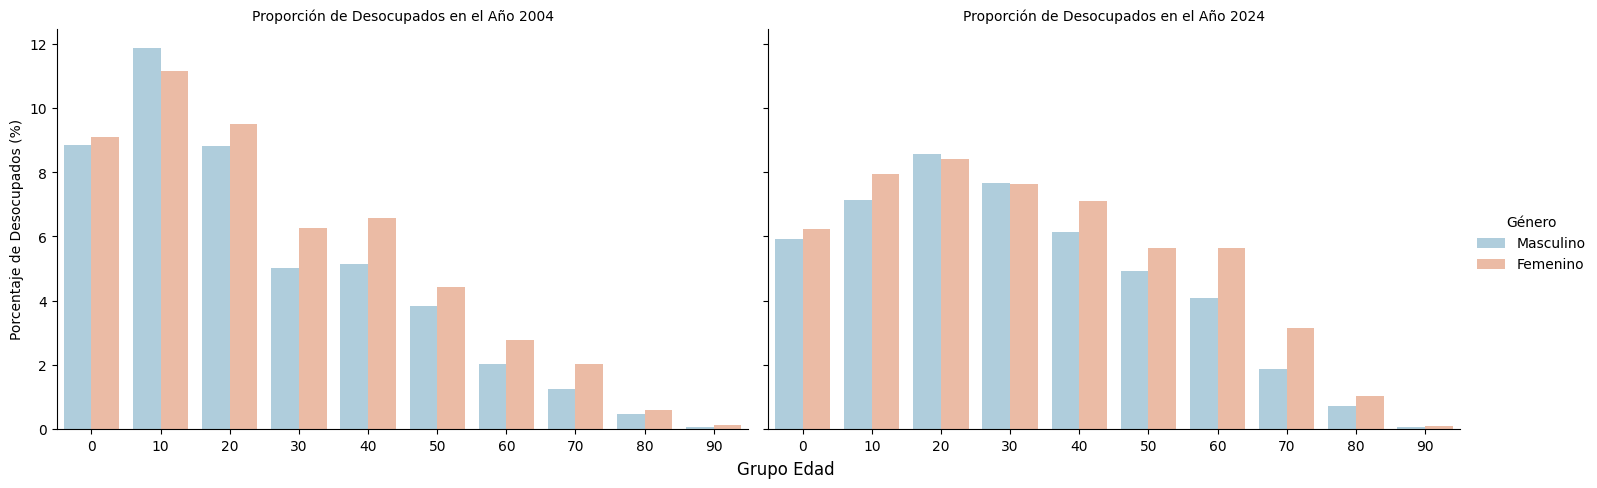

In [97]:
# Iterar sobre la columna 'estado' y creamos una nueva columna 'desocupado'
# que vale 1 si lo son, 0 sino
respondieron.loc[(respondieron['estado'] == 2), 'desocupado'] = 1
respondieron.loc[respondieron['estado'].isin([1, 3, 4]), 'desocupado'] = 0

# chequeamos que se haya hecho bien
print(respondieron[['estado', 'desocupado']].sample(100))

anos = [2004, 2024]

# Recorremos cada año y contamos las ocurrencias de "desocupado"
for ano in anos:
    # Usamos la funcion de contador en 'desocupado' para el corriente año
    # Recordemos: funcion(dataframe, columna, condicion, año)
    count_desocupados = contador(respondieron, 'desocupado', 1, anos=[ano])
    print(f"La cantidad de personas desocupadas en el año {str(ano)} fue {count_desocupados}")

# Agrupamos por año, nivel educativo y si están desocupados
composicion_desocupados = respondieron.groupby(['ano4', 'nivel_ed', 'desocupado']).size().reset_index(name='count')

# Calcular la proporción de desocupados por nivel educativo y por año
composicion_desocupados['total_por_ano'] = composicion_desocupados.groupby('ano4')['count'].transform('sum')
composicion_desocupados['proporcion_desocupados'] = composicion_desocupados['count'] / composicion_desocupados['total_por_ano']

# Filtrar solo los desocupados (desocupado == 1)
composicion_desocupados = composicion_desocupados[composicion_desocupados['desocupado'] == 1]

# Mapeamos valores numericos de nivel_ed a su descripcion
nivel_ed_mapeo = {
    1: "Primaria Incompleta",
    2: "Primaria Completa",
    3: "Secundaria Incompleta",
    4: "Secundaria Completa",
    5: "Superior Incompleta",
    6: "Superior Completa",
    7: "Sin instrucción",
    9: "Ns./Nr."
}
composicion_desocupados['nivel_ed'] = composicion_desocupados['nivel_ed'].map(nivel_ed_mapeo)


#GRAFICO 1
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=composicion_desocupados, x='nivel_ed', y='proporcion_desocupados', hue='ano4', palette='RdYlGn')

ax.set_ylabel("Porcentaje de Desocupados (%)", fontsize=12)
ax.set_ylim(0, composicion_desocupados['proporcion_desocupados'].max() * 1.1) # Limites del eje x
ax.set_yticklabels([f'{float(y * 100)}' for y in ax.get_yticks()]) # Queremos ver porcentajes

# Ajustar las etiquetas del eje x para que se muestren en varios reglones
labels = ax.get_xticklabels()
new_labels = [label.get_text().replace(" ", "\n") for label in labels]
ax.set_xticklabels(new_labels, rotation=0, ha='center', fontsize=10)

# Personalizar el gráfico
plt.title("Proporción de Desocupados por Nivel Educativo (2004 vs 2024)", fontsize=16, fontweight='bold')
plt.xlabel("Nivel Educativo", fontsize=12)
plt.legend(title="Año", loc="upper right")
plt.tight_layout()
plt.show()


# Crear la nueva columna 'edad_grupo' agrupada de a 10 años
respondieron['edad_grupo'] = (respondieron['ch06'] // 10) * 10

# Agrupar por 'edad_grupo', 'desocupado' y 'ano4' para contar las cantidades
composicion_desocupados_edad = respondieron.groupby(['ano4', 'edad_grupo', 'desocupado']).size().reset_index(name='count')

# Calcular la proporción de desocupados por grupo de edad y por año
composicion_desocupados_edad['total_por_ano'] = composicion_desocupados_edad.groupby('ano4')['count'].transform('sum')
composicion_desocupados_edad['proporcion_desocupados'] = composicion_desocupados_edad['count'] / composicion_desocupados_edad['total_por_ano']

# Filtrar solo los desocupados (desocupado == 1)
composicion_desocupados_edad = composicion_desocupados_edad[composicion_desocupados_edad['desocupado'] == 1]

# GRAFICO 2
# Gráfico de barras de proporciones de desocupados por grupo de edad y año
plt.figure(figsize=(10, 6))
eje = sns.barplot(data=composicion_desocupados_edad, x='edad_grupo', y='proporcion_desocupados', hue='ano4', palette='Accent_r')
eje.set_ylabel("Porcentaje de Desocupados (%)", fontsize=12)
eje.set_yticklabels([f'{round(float(y * 100), 2)}' for y in eje.get_yticks()]) # Porcentajes con 2 decimales

# Filtrar valores únicos que no sean NaN en 'edad_grupo' y convertirlos a int para etiquetas del eje x
# Como arranca desde 0 pero no hay valores observaciones allí, lo ajustamos
edad_grupos_unicos = [int(x+10) for x in sorted(respondieron['edad_grupo'].dropna().unique())]
eje.set_xticklabels([f'{x}' for x in edad_grupos_unicos])

# Personalizar el gráfico
plt.title("Desocupados por Edad (2004 vs 2024)", fontsize=16, fontweight='bold')
plt.xlabel("Grupo etáreo", fontsize=12)
plt.legend(title="Año", loc="upper right")
plt.tight_layout()
plt.show()


# Agrupar por 'ano4', 'edad_grupo', 'ch04' (género) para contar las cantidades
composicion_genero_edad = respondieron.groupby(['ano4', 'edad_grupo', 'ch04']).size().reset_index(name='count')

# Calcular la proporción de desocupados por grupo de edad y por año
composicion_genero_edad['total_por_ano'] = composicion_genero_edad.groupby('ano4')['count'].transform('sum')
composicion_genero_edad['proporcion_genero'] = composicion_genero_edad['count'] / composicion_genero_edad['total_por_ano']

# Mapeo para los géneros
composicion_genero_edad['Genero'] = composicion_genero_edad['ch04'].map({1: 'Masculino', 2: 'Femenino'})

#GRAFICO 3

# Gráfico de barras facetadas por año
g = sns.FacetGrid(composicion_genero_edad, col="ano4", height=5, aspect=1.5, sharey=True)
g.map_dataframe(sns.barplot, x='edad_grupo', y='proporcion_genero', hue='Genero', palette='RdBu_r', dodge=True)
g.set_axis_labels("", "")
g.set_titles("Proporción de Desocupados en el Año {col_name}")
g.add_legend(title="Género")

# Ajuste del diseño final para eliminar ejes duplicados y centrar la etiqueta del eje x
for ax in g.axes.flat:
    ax.set_ylabel("Porcentaje de Desocupados (%)")

# Establecer las etiquetas en formato de porcentaje para todos los subplots
for ax in g.axes.flat:
    ax.set_yticklabels([f'{int(round(y * 100))}' for y in ax.get_yticks()])

for ax in g.axes.flat:
    # Establecer posiciones para que coincidan con el número de valores únicos de 'edad_grupo'
    edad_grupos_un = sorted(respondieron['edad_grupo'].dropna().unique())

    ax.set_xticks(range(len(edad_grupos_un)))
    ax.set_xticklabels([f'{int(x)}' for x in edad_grupos_un])

plt.subplots_adjust(top=0.9, bottom=0.1)
g.fig.text(0.5, 0.01, "Grupo Edad", ha="center", fontsize=12)
# Graficamos
plt.show()


In [ ]:
# Guardar los DataFrames filtrados en archivos de Excel
respondieron.to_excel('respondieron.xlsx', index=False)

(10187, 186)
(10193, 182)


Ejercicio 10

In [98]:
# Procedemos con la formula de desocupacion oficial siendo : Tasa de desocupacion = (Desocupados/PEA)*100
# Y tasa de desocupacion alternativa = (Desocupados/ PET) * 100

def calcular_tasas(df):

    # Calculamos la tasa de desocupación según el INDEC
    tasa_des_indec = (contador(respondieron,'desocupado', 1) / contador(respondieron, 'PEA', 1)) * 100

    # Calculamos la tasa de desocupación alternativa (desocupados sobre PET)
    tasa_des_alternativa = (contador(respondieron, 'desocupado', 1) / (contador(respondieron, 'PET', 1))) * 100

    # Retornamos los resultados
    return {"Tasa de Desocupación INDEC": round(float(tasa_des_indec),2), "Tasa de Desocupación Alternativa": round(float(tasa_des_alternativa),2)}

# Llamamos a la función con el DataFrame `respondieron`
resultados = calcular_tasas(respondieron)
print(resultados)


{'Tasa de Desocupación INDEC': 8.06, 'Tasa de Desocupación Alternativa': 5.12}


# TP 2: Ejercicios

In [99]:
# IMPORTANTE: Correr los ejs anteriores para tener el dataframe respondieron

# Por las dudas vamos a copiar de nuevo el dataframe
df_mapeado = df_combined_tydy.copy()

df_mapeado, columnas_mapeadas = mapear_categoricos_con_alertas(df_mapeado)

⚠️ ch10: 256 valores válidos se convirtieron en NaN tras mapear.
   Ejemplos perdidos: [0.0 'Ns./Nr.']
⚠️ ch11: 6739 valores válidos se convirtieron en NaN tras mapear.
   Ejemplos perdidos: [0.0]
⚠️ ch12: 749 valores válidos se convirtieron en NaN tras mapear.
   Ejemplos perdidos: [0.0 'Ns./Nr.']
⚠️ ch13: 748 valores válidos se convirtieron en NaN tras mapear.
   Ejemplos perdidos: [0.0]
⚠️ ch14: 2253 valores válidos se convirtieron en NaN tras mapear.
   Ejemplos perdidos: ['  ']
⚠️ estado: 5 valores válidos se convirtieron en NaN tras mapear.
   Ejemplos perdidos: ['Entrevista individual no realizada (no respuesta al cuestion']
⚠️ cat_ocup: 6076 valores válidos se convirtieron en NaN tras mapear.
   Ejemplos perdidos: [0.0]
⚠️ cat_inac: 4253 valores válidos se convirtieron en NaN tras mapear.
   Ejemplos perdidos: [0.0]
⚠️ pp02c1: 9876 valores válidos se convirtieron en NaN tras mapear.
   Ejemplos perdidos: [0.0]
⚠️ pp02c2: 9876 valores válidos se convirtieron en NaN tras mapear.


Ejercicio 1 y 2

In [100]:
print('\nDimensión:\n', df_combined_tydy.shape)



Dimensión:
 (10193, 182)


Drop de variables inútiles

In [101]:
var_inut = ['h15', 'trimestre',
       'region', 'pondera', 'nro_hogar', 'componente']

df_mapeado = df_mapeado.drop(columns=var_inut)
print('\nDimensión:\n', df_mapeado.shape)


Dimensión:
 (10193, 176)


Calculo de dimensión de dummies

In [102]:
def calcular_dimension_dummies(df, variables_categoricas):
    """
    Calcula cuántas dummies se generarían por cada variable categórica
    y cuál sería la nueva dimensión total del DataFrame si aplicamos one-hot encoding.

    Parámetros:
    - df: DataFrame ya mapeado con categorías en texto
    - variables_categoricas: lista de nombres de columnas categóricas (en minúsculas)

    Retorna:
    - DataFrame resumen con columnas ['variable', 'num_dummies']
    - Total de columnas nuevas
    - Dimensión estimada del DataFrame después del one-hot encoding
    """
    # Lista e índice vacíos para guardar cada variables y sus nuevas dummies
    # y contar la cantidad todal de dummies creadas
    resumen = []
    total_nuevas = 0

    # Iterar en cada columna mapeada
    for var in variables_categoricas:
        if var in df.columns:
            categorias_validas = df[var].dropna().unique() # solo valores unicos
            num_dummies = len(categorias_validas)
            resumen.append({'variable': var, 'num_dummies': num_dummies})
            total_nuevas += num_dummies

    resumen_df = pd.DataFrame(resumen).sort_values('num_dummies', ascending=False).reset_index(drop=True)
    nueva_dim = df.shape[1] - len(resumen_df) + total_nuevas

    print(f"Variables categóricas analizadas: {len(resumen_df)}")
    print(f"Total de dummies nuevas: {total_nuevas}")
    print(f"Nueva dimensión estimada del DataFrame: ({df.shape[0]}, {nueva_dim})")

    return resumen_df, total_nuevas, nueva_dim

resumen_dummies, total_dummies, nueva_dim = calcular_dimension_dummies(df_mapeado, columnas_mapeadas)
resumen_dummies.head()  # Ver las variables más costosas, vemos que los deciles están


Variables categóricas analizadas: 53
Total de dummies nuevas: 343
Nueva dimensión estimada del DataFrame: (10193, 466)


,variable,num_dummies
0,pdecindr,13
1,adecindr,13
2,idecindr,13
3,rdecindr,13
4,pp04c,13


Ejercicio 3

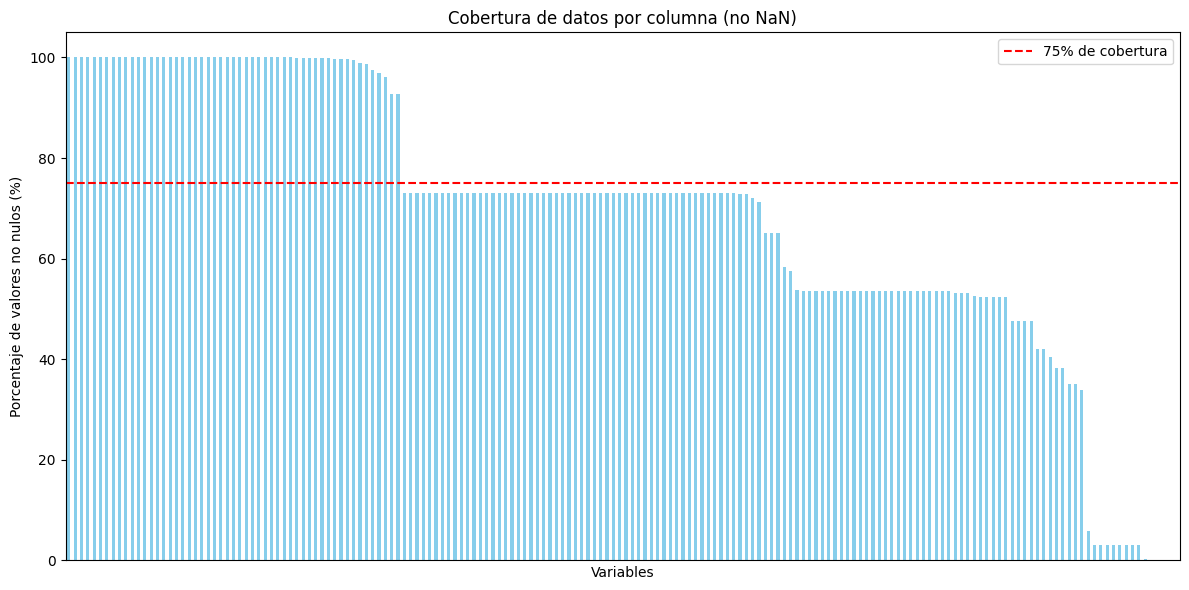

In [103]:
def graficar_porcentaje_no_nan(df):
    """
    Gráfico del porcentaje de valores NO nulos (completos) por columna.
    Incluye líneas guía para cobertura mínima sugerida.
    """
    non_nan_ratio = df.notna().mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(12, 6))
    non_nan_ratio.plot(kind='bar', color='skyblue')
    plt.axhline(y=75, color='red', linestyle='--', label='75% de cobertura')
    plt.ylabel("Porcentaje de valores no nulos (%)")
    plt.xlabel("Variables")
    plt.title("Cobertura de datos por columna (no NaN)")
    plt.xticks([])
    plt.legend()
    plt.tight_layout()
    plt.show()

    return non_nan_ratio

cobertura = graficar_porcentaje_no_nan(df_mapeado)

In [104]:
def columnas_con_poder_y_balance(df, n_total=df_mapeado.shape[0], min_abs=5000, min_ratio=0.75, min_por_categoria=1):
    """
    Filtra columnas con suficiente poder estadístico:
    - Al menos `min_abs` observaciones válidas
    - Al menos `min_ratio` del total
    - Si es categórica, cada categoría tiene al menos `min_por_categoria` observaciones
    """
    columnas_validas = []
    for col in df.columns:
        serie = df[col]
        n_valid = serie.notna().sum()
        prop_valid = n_valid / n_total

        if n_valid >= min_abs and prop_valid >= min_ratio:
            # Si es categórica (dtype object o category o string), controlamos el balance por categoría
            if serie.dtype == object or pd.api.types.is_categorical_dtype(serie):
                counts = serie.value_counts(dropna=True)
                if (counts >= min_por_categoria).all():
                    columnas_validas.append(col)
            else:
                columnas_validas.append(col)

    print(f"Columnas totales: {df.shape[1]}")
    print(f"Columnas que cumplen todos los criterios: {len(columnas_validas)}")
    return columnas_validas

columnas_finales = columnas_con_poder_y_balance(df_mapeado)
df_modelo = df_mapeado[columnas_finales]
print(df_modelo.columns)

Columnas totales: 176
Columnas que cumplen todos los criterios: 53
Index(['codusu', 'ano4', 'mas_500', 'aglomerado', 'ch03', 'ch04', 'ch06',
       'ch07', 'ch08', 'ch09', 'ch10', 'ch12', 'ch13', 'ch15', 'ch16',
       'nivel_ed', 'estado', 'p21', 'pdecocur', 'adecocur', 'tot_p12', 'p47t',
       'decindr', 'idecindr', 'rdecindr', 'pdecindr', 'adecindr', 'v2_m',
       'v3_m', 'v4_m', 'v5_m', 'v8_m', 'v9_m', 'v10_m', 'v11_m', 'v12_m',
       'v18_m', 'v19_am', 'v21_m', 't_vi', 'itf', 'decifr', 'idecifr',
       'rdecifr', 'pdecifr', 'adecifr', 'ipcf', 'deccfr', 'ideccfr', 'rdeccfr',
       'pdeccfr', 'adeccfr', 'id_persona'],
      dtype='object')


<ipython-input-104-adfbcb9b41df>:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if serie.dtype == object or pd.api.types.is_categorical_dtype(serie):
<ipython-input-104-adfbcb9b41df>:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if serie.dtype == object or pd.api.types.is_categorical_dtype(serie):
<ipython-input-104-adfbcb9b41df>:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if serie.dtype == object or pd.api.types.is_categorical_dtype(serie):
<ipython-input-104-adfbcb9b41df>:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if serie.dtype == object or pd.api.types.is_ca

Variables para trabajar

In [105]:
variables_manual = ['aglomerado', 'ch04', 'ch06', 'ch07', 'nivel_ed', 'ch08', 'estado',
                    'ano4', 'ipcf', 'p47t', 'rdecindr', 'itf', 'rdecifr', 'rdeccfr',
                    'v10_m', 'v2_m', 'v5_m', 'id_persona', 't_vi', 'codusu']
print(len(variables_manual))

df_modelo_manual = df_mapeado[variables_manual]

20


In [106]:
# Detectar variables categóricas (tipo object o categoricals)
excluir_dummies = ['id_persona', 'ano4', 'codusu']
categ_vars = [
    col for col in df_modelo_manual.columns
    if df_modelo_manual[col].dtype == 'object' and col not in excluir_dummies
]
print(categ_vars)

for var in categ_vars:
    print(f"\n {var} — valores únicos:")
    print(df_modelo_manual[var].dropna().unique())

# Lista de valores a convertir en NaN
valores_a_nan = [
    'Ns./Nr.',
    'Entrevista no realizada',
    'Entrevista individual no realizada',
    'No respuesta de ingresos'
]

# Aplicar reemplazo en variables categóricas
df_modelo_manual.loc[:, categ_vars] = df_modelo_manual.loc[:, categ_vars].replace(valores_a_nan, np.nan)


# Crear dummies
df_manual_dummies = pd.get_dummies(df_modelo_manual, columns=categ_vars, drop_first=True)

print(df_manual_dummies.shape)

# Eliminamos valores faltantes
df_manual_dummies_clean = df_manual_dummies.dropna()
print(df_manual_dummies_clean.shape)

print(df_manual_dummies_clean.columns)

['aglomerado', 'ch04', 'ch07', 'nivel_ed', 'ch08', 'estado', 'rdecindr', 'rdecifr', 'rdeccfr']

 aglomerado — valores únicos:
['Posadas' 'Gran Resistencia' 'Corrientes' 'Formosa']

 ch04 — valores únicos:
['Mujer' 'Varón']

 ch07 — valores únicos:
['Unido' 'Viudo' 'Soltero' 'Casado' 'Separado o divorciado']

 nivel_ed — valores únicos:
['Superior Universitaria Completa'
 'Primaria Incompleta (incluye educación especial)'
 'Secundaria Incompleta' 'Primaria Completa'
 'Superior Universitaria Incompleta' 'Sin instrucción'
 'Secundaria Completa']

 ch08 — valores únicos:
['Obra social (incluye PAMI)' 'No paga ni le descuentan'
 'Mutual/Prepaga/Servicio de emergencia'
 'Obra social y mutual/prepaga/servicio de emergencia'
 'Planes y seguros públicos' 'Ns./Nr.']

 estado — valores únicos:
['Inactivo' 'Ocupado' 'Menor de 10 años' 'Desocupado'
 'Entrevista individual no realizada (no respuesta al cuestionario)']

 rdecindr — valores únicos:
['Decil 7' 'Decil 4' 'Decil 6' 'Sin ingresos' 'Decil 

# TP 2: Parte 2

In [107]:
df_manual_dummies_clean = df_manual_dummies_clean.copy()
respondieron = respondieron.copy()

# Convertimos los nombres de columnas a minúsculas para que coincidan con los del diccionario
respondieron.columns = respondieron.columns.str.lower()
df_manual_dummies_clean.columns = df_manual_dummies_clean.columns.str.lower()

# Solo dejamos las que coinciden
df_manual_respondieron = df_manual_dummies_clean[
    df_manual_dummies_clean['id_persona'].isin(respondieron['id_persona'])
].copy()


print(f"Total en df_manual_dummies_clean: {df_manual_dummies_clean.shape[0]}")
print(f"Total en respondieron: {respondieron.shape[0]}")
print(f"Total en df_manual_respondieron (filtrado): {df_manual_respondieron.shape[0]}")

Total en df_manual_dummies_clean: 9661
Total en respondieron: 10187
Total en df_manual_respondieron (filtrado): 9661


Clustering

Personas con más de una categoría educativa activa: 0


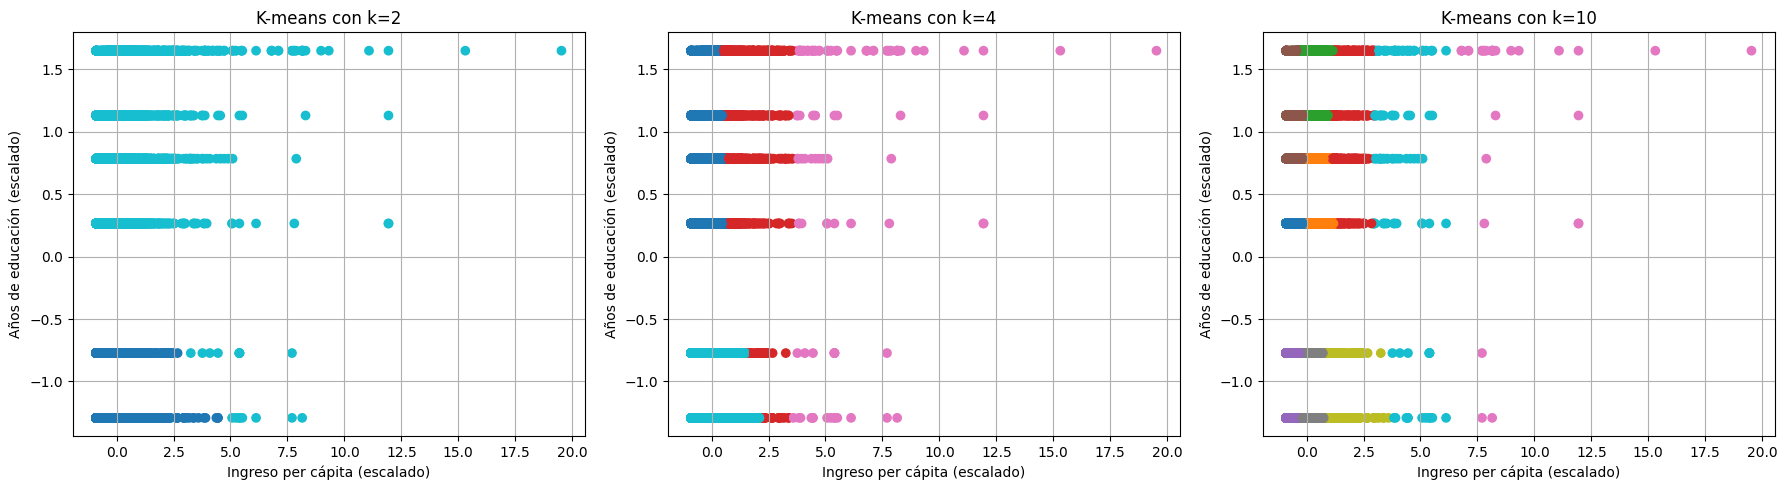

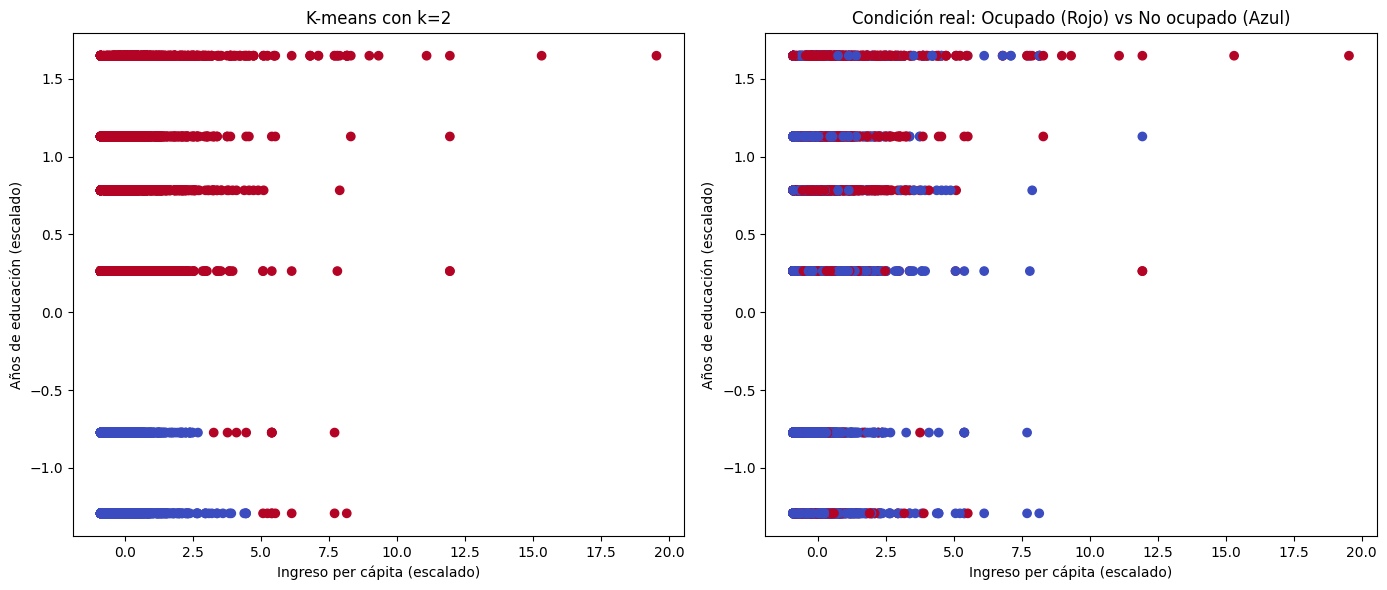

In [109]:
# copia de trabajo
df_cluster_manual = df_manual_respondieron.copy()

# Mapeo manual del nivel educativo a años estimados
ponderacion_nivel_ed = {
    'nivel_ed_sin instrucción': 0,
    'nivel_ed_primaria incompleta (incluye educación especial)': 3,
    'nivel_ed_secundaria incompleta': 9,
    'nivel_ed_secundaria completa': 12,
    'nivel_ed_superior universitaria incompleta': 14,
    'nivel_ed_superior universitaria completa': 17
}

# Aplicar el mapeo
# Asegurar que todas las columnas estén presentes
for col in ponderacion_nivel_ed:
    if col not in df_manual_dummies_clean.columns:
        df_manual_dummies_clean[col] = 0

# Calcular años de educación como suma ponderada
df_manual_dummies_clean['anios_educ'] = sum(
    df_manual_dummies_clean[col] * anios for col, anios in ponderacion_nivel_ed.items())

nivel_cols = list(ponderacion_nivel_ed.keys())
conteo_dummies = df_manual_dummies_clean[nivel_cols].sum(axis=1)

# Chequear que no se haya duplicado alguna suma
print("Personas con más de una categoría educativa activa:", (conteo_dummies > 1).sum())

# Nos aseguramos de tener solo las columnas numéricas necesarias
df_cluster_manual_ingreso_educ = df_manual_dummies_clean[['ipcf', 'anios_educ']].dropna().to_numpy()


# Cantidas de K en clusters
k_n = [2, 4, 10]
modelos = []

# Estandarización
scaler = StandardScaler()
cluster_ingreso_educ = scaler.fit_transform(df_cluster_manual_ingreso_educ)

# Ejecutar K-means con n_init=20
for k in k_n:
    kmeans = KMeans(n_clusters=k, random_state=10, init="random", n_init=20)
    kmeans.fit(cluster_ingreso_educ)
    modelos.append(kmeans)

# Graficar los clusters
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, kmeans in enumerate(modelos):
    axes[i].scatter(cluster_ingreso_educ[:, 0], cluster_ingreso_educ[:, 1], c=kmeans.labels_, cmap='tab10')
    axes[i].set_title(f"K-means con k={k_n[i]}")
    axes[i].set_xlabel("Ingreso per cápita (escalado)")
    axes[i].set_ylabel("Años de educación (escalado)")
    axes[i].grid(True)

plt.tight_layout()
plt.show()


# Cluster con estado
# Dataset con ingreso, educación y estado ocupado
df_cluster_estado = df_manual_dummies_clean[['ipcf', 'anios_educ', 'estado_ocupado']].dropna()

# Guardamos la variable real (ocupado o no) para graficar después
estado_real = df_cluster_estado['estado_ocupado'].to_numpy()

# Matriz solo con ingreso y educación
X_estado = df_cluster_estado[['ipcf', 'anios_educ']].to_numpy()

# estandarizamos para K-means
scaler = StandardScaler()
X_estado_scaled = scaler.fit_transform(X_estado)

# K-means con K=2
kmeans2 = KMeans(n_clusters=2, random_state=10, init="random", n_init=20)
kmeans2.fit(X_estado_scaled)

# Graficamos clusters vs estado real
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Clustering
axes[0].scatter(X_estado_scaled[:, 0], X_estado_scaled[:, 1], c=kmeans2.labels_, cmap='coolwarm')
axes[0].set_title("K-means con k=2")
axes[0].set_xlabel("Ingreso per cápita (escalado)")
axes[0].set_ylabel("Años de educación (escalado)")

# Estado real
axes[1].scatter(X_estado_scaled[:, 0], X_estado_scaled[:, 1], c=estado_real, cmap='coolwarm')
axes[1].set_title("Condición real: Ocupado (Rojo) vs No ocupado (Azul)")
axes[1].set_xlabel("Ingreso per cápita (escalado)")
axes[1].set_ylabel("Años de educación (escalado)")

plt.tight_layout()
plt.show()

Dendograma

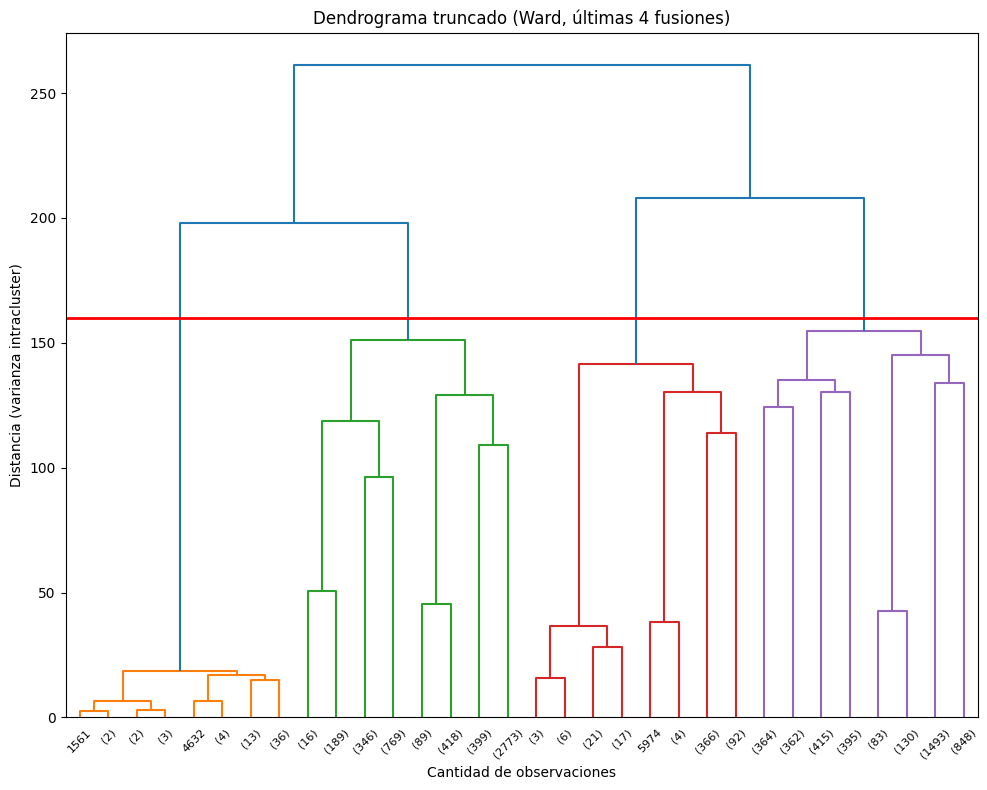

In [110]:
df_jerarquico = df_manual_respondieron.drop(columns=['id_persona', 'codusu']).dropna()

jerarquico_scaled = scaler.fit_transform(df_jerarquico)

# Algoritmo de linkage: ward minimiza varianza interna de los grupos
Dendograma = linkage(jerarquico_scaled, method='ward')

# Dendrograma
fig, ax = plt.subplots(figsize=(10, 8))
dendrogram(Dendograma, truncate_mode='level', p=4, ax=ax)
ax.set_title("Dendrograma truncado (Ward, últimas 4 fusiones)")
ax.set_xlabel("Cantidad de observaciones")
ax.set_ylabel("Distancia (varianza intracluster)")
ax.axhline(y=160, c='red', linewidth=2)
plt.tight_layout()
plt.show()

Histogramas y Kernels

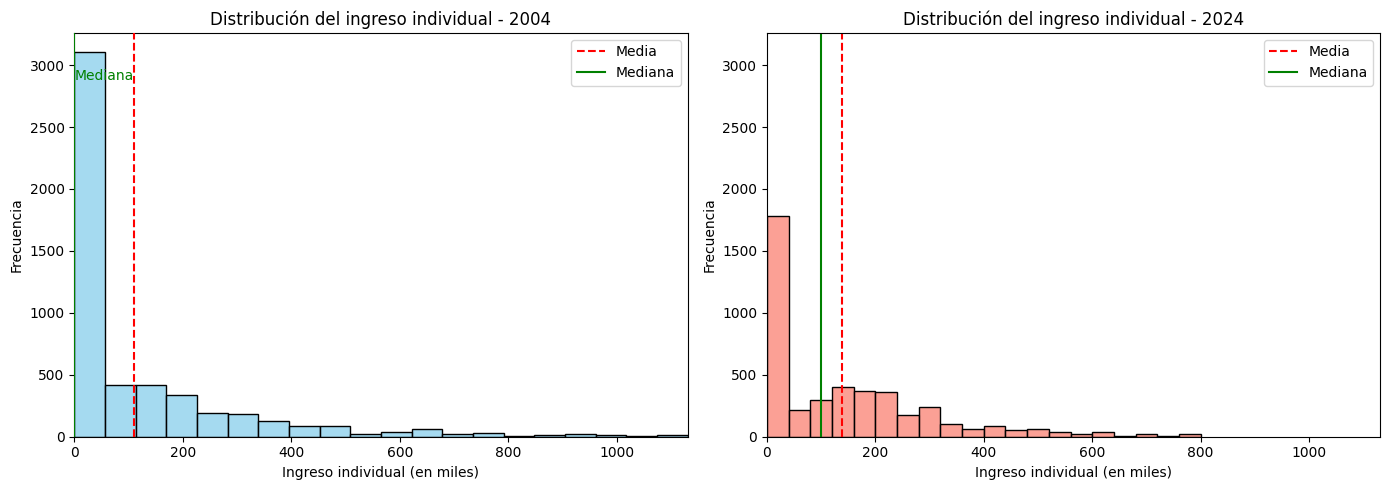

In [111]:
df_histograma = df_manual_respondieron[['p47t', 'ano4']]

# Filtrar entre percentil 1 y 99 por año
df_filtrados = []

for año in [2004, 2024]:
    subset = df_histograma[df_histograma['ano4'] == año]
    p1 = subset['p47t'].quantile(0.01)
    p99 = subset['p47t'].quantile(0.99)
    subset_filtrado = subset[(subset['p47t'] >= p1) & (subset['p47t'] <= p99)]
    df_filtrados.append(subset_filtrado)

df_histograma_filtered = pd.concat(df_filtrados)

data_2004 = df_histograma_filtered[df_histograma_filtered['ano4'] == 2004]['p47t']
data_2024 = df_histograma_filtered[df_histograma_filtered['ano4'] == 2024]['p47t']

# Histograma + líneas de media y mediana
mean_2004 = data_2004.mean()
median_2004 = data_2004.median()

mean_2024 = data_2024.mean()
median_2024 = data_2024.median()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins= 20
# 2004
hist_2004 = sns.histplot(data_2004, bins=bins, ax=axes[0], kde=False, color='skyblue')
axes[0].axvline(mean_2004, color='red', linestyle='--', linewidth=1.5, label='Media', zorder=3)
axes[0].axvline(median_2004, color='green', linestyle='-', linewidth=1.5, label='Mediana', zorder=4)
axes[0].text(median_2004 + 500, 3200 * 0.9, 'Mediana', color='green', fontsize=10)
axes[0].set_title("Distribución del ingreso individual - 2004")
axes[0].set_xlabel("Ingreso individual (en miles)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()


# 2024
hist_2024 = sns.histplot(data_2024, bins=bins, ax=axes[1], kde=False, color='salmon')
axes[1].axvline(mean_2024, color='red', linestyle='--', linewidth=1.5, label='Media')
axes[1].axvline(median_2024, color='green', linestyle='-', linewidth=1.5, label='Mediana')
axes[1].set_title("Distribución del ingreso individual - 2024")
axes[1].set_xlabel("Ingreso individual (en miles)")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

# Calcular los límites mínimos y máximos de ingreso en ambos conjuntos
min_x = min(data_2004.min(), data_2024.min())
max_x = max(data_2004.max(), data_2024.max())

# Escala común para los ejes X e Y

# Obtener altura máxima de ambos histogramas
max_y = max(hist_2004.get_ylim()[1], hist_2024.get_ylim()[1])
for ax in axes:
    ax.set_ylim(0, max_y)
    ax.set_xlim(min_x, max_x)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x/1000)}'))
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Kernels

In [112]:
# Copia
df_kernels = df_manual_dummies_clean.copy()

# Variable dummy al menos un desocupado en el hogar
df_kernels['hogar_desocupado'] = df_kernels['estado_ocupado'] == 0
hogar_desocupado_flag = df_kernels.groupby('codusu')['hogar_desocupado'].any().astype(int).rename("alguno_desocupado")

# Sumar ingreso total por hogar (solo ocupados con ingreso positivo)
df_ocupados = df_kernels[(df_kernels['estado_ocupado'] == 1) & (df_kernels['p47t'] > 0)]
ingreso_hogar = df_ocupados.groupby('codusu')['p47t'].sum().rename("ingreso_total_hogar")

# Año del hogar: tomamos el primero (debería ser igual para todos en el hogar)
ano_hogar = df_kernels.groupby('codusu')['ano4'].first()

# Combinar todo en un solo DataFrame
df_hogares = pd.concat([ingreso_hogar, hogar_desocupado_flag, ano_hogar], axis=1).dropna()




 Kernel: TOPHAT


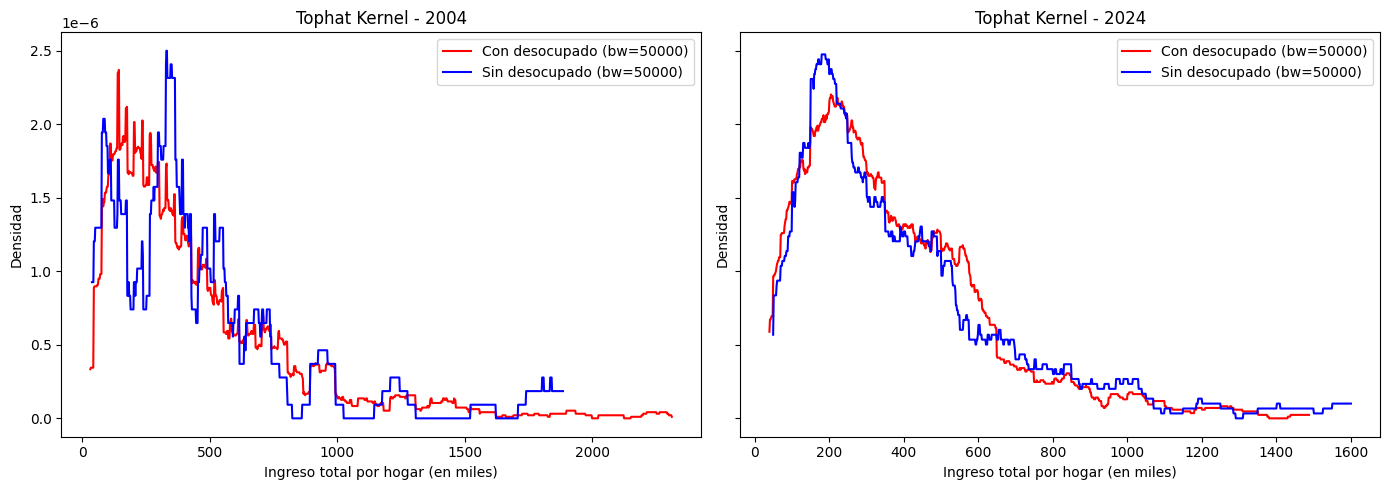


 Kernel: GAUSSIAN


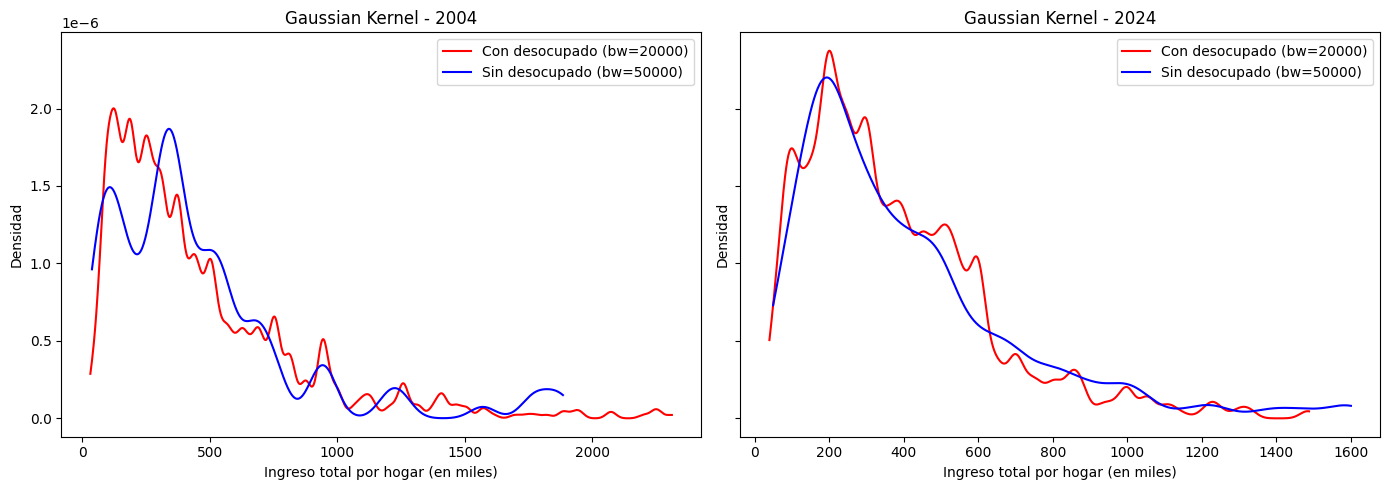


 Kernel: EPANECHNIKOV


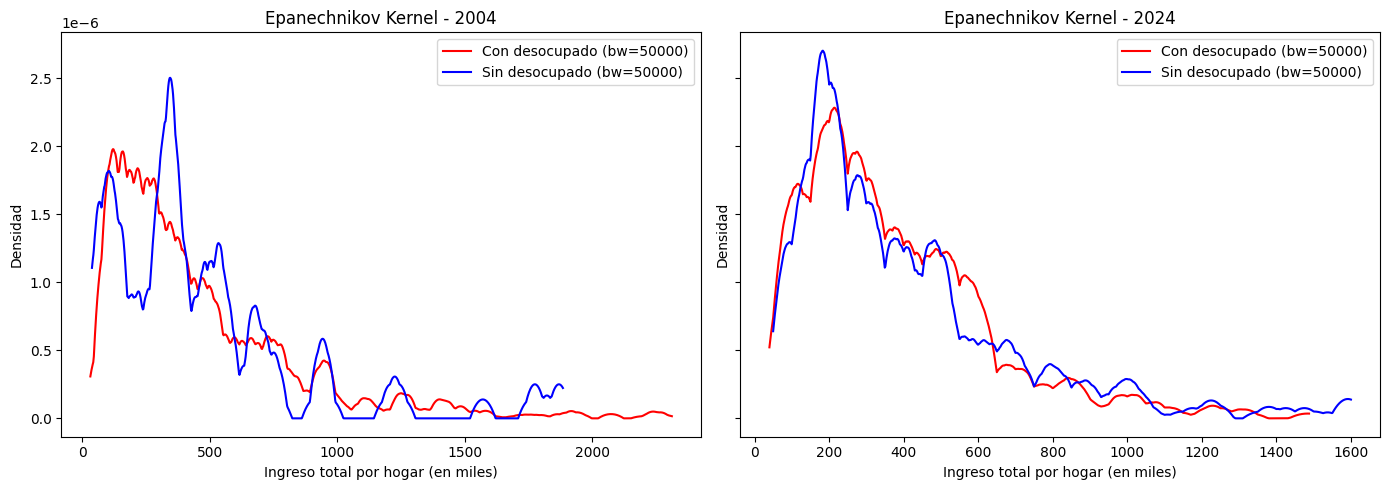

In [121]:
# lista de kernels para usar
kernels = ['tophat', 'gaussian', 'epanechnikov']

# funcion que filtra outliers
def filtrar_outliers_percentil(data, lower=0.01, upper=0.99):
    p1 = np.percentile(data, lower * 100)
    p99 = np.percentile(data, upper * 100)
    return data[(data >= p1) & (data <= p99)]

# Función para decidir el bandwidth
def bandwidth_optimo(data, kernel):
    data = data[:, np.newaxis]

    if kernel in ['gaussian']:  # seguro para búsqueda de bandwidth
        grid = GridSearchCV(
            KernelDensity(kernel=kernel),
            {'bandwidth': np.linspace(20000, 50000, 100)},
            cv=5
        )
        grid.fit(data)
        return grid.best_params_['bandwidth']
    else:
        # Retornar un valor razonable por defecto para kernels problemáticos
        return 50000

# Función que otorga formato al plot de densidad del kernel
def plot_kde(data, label, color, ax, bandwidth, kernel):
    data = data[:, np.newaxis]
    kde = KernelDensity(kernel=kernel, bandwidth=bandwidth).fit(data)
    x_d = np.linspace(data.min(), data.max(), 1000)[:, np.newaxis]
    log_dens = kde.score_samples(x_d)
    ax.plot(x_d[:, 0], np.exp(log_dens), label=label, color=color)

# Se itera en la lista de kernels para crear los gráficos
for kernel in kernels:
    print(f"\n Kernel: {kernel.upper()}")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for i, año in enumerate([2004, 2024]):
        ax = axes[i]
        df_subset = df_hogares[df_hogares['ano4'] == año]

        # Datos con filtro
        data_con = filtrar_outliers_percentil(
            df_subset[df_subset['alguno_desocupado'] == 1]['ingreso_total_hogar'].dropna().values
        )
        data_sin = filtrar_outliers_percentil(
            df_subset[df_subset['alguno_desocupado'] == 0]['ingreso_total_hogar'].dropna().values
        )

        # Bandwidths óptimos
        bw_con = bandwidth_optimo(data_con, kernel)
        bw_sin = bandwidth_optimo(data_sin, kernel)

        # Plot
        plot_kde(data_con, f'Con desocupado (bw={int(bw_con)})', 'red', ax, bw_con, kernel)
        plot_kde(data_sin, f'Sin desocupado (bw={int(bw_sin)})', 'blue', ax, bw_sin, kernel)

        ax.set_title(f"{kernel.capitalize()} Kernel - {año}")
        ax.set_xlabel("Ingreso total por hogar (en miles)")
        ax.set_ylabel("Densidad")
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x/1000)}'))
        ax.legend()

    plt.tight_layout()
    plt.show()

Ingreso promedio por hogar y diferencia relativa:

      Sin desocupados  Con algún desocupado  Diferencia (%)
ano4                                                       
2004        493380.16             486574.72            1.40
2024        428720.04             394467.47            8.68


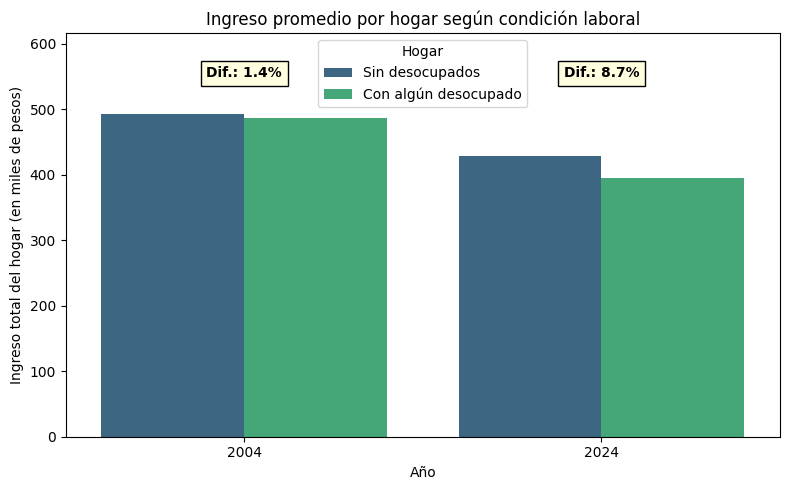

In [117]:
# Agrupamos por año y tipo de hogar
resumen_ingresos = df_hogares.groupby(['ano4', 'alguno_desocupado'])['ingreso_total_hogar'].mean().unstack()

# Renombramos columnas para mayor claridad
resumen_ingresos.columns = ['Sin desocupados', 'Con algún desocupado']

# Calculamos diferencia porcentual
resumen_ingresos['Diferencia (%)'] = (
    (resumen_ingresos['Sin desocupados'] - resumen_ingresos['Con algún desocupado']) /
    resumen_ingresos['Con algún desocupado']
) * 100

# Mostramos
print("Ingreso promedio por hogar y diferencia relativa:\n")
print(resumen_ingresos.round(2))


# Reset index para convertir 'ano4' en columna
resumen_plot = resumen_ingresos.reset_index().melt(id_vars='ano4',
                                                    value_vars=['Sin desocupados', 'Con algún desocupado'],
                                                    var_name='Tipo de hogar',
                                                    value_name='Ingreso promedio')

# Definimos un espacio extra en la escala Y para posicionar bien los recuadros
y_max = resumen_ingresos[['Sin desocupados', 'Con algún desocupado']].values.max()
y_lim_top = y_max * 1.25

# Graficamos
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=resumen_plot, x='ano4', y='Ingreso promedio', hue='Tipo de hogar', palette='viridis', ax=ax)

# Títulos y ejes
ax.set_title("Ingreso promedio por hogar según condición laboral")
ax.set_ylabel("Ingreso total del hogar (en miles de pesos)")
ax.set_xlabel("Año")
ax.legend(title='Hogar')
ax.set_ylim(0, y_lim_top)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x/1000)}'))

# Recuadros con la diferencia porcentual más arriba
for i, año in enumerate(resumen_ingresos.index):
    diferencia = resumen_ingresos.loc[año, 'Diferencia (%)']
    texto = f"Dif.: {diferencia:.1f}%"
    ax.text(i, y_lim_top * 0.90, texto,
            ha='center', va='center', fontsize=10, fontweight='bold',
            bbox=dict(facecolor='lightyellow', edgecolor='black'))

plt.tight_layout()
plt.show()